In [51]:
from pathlib import Path
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, linregress
from scipy.optimize import Bounds, LinearConstraint, minimize, SR1
from matplotlib.lines import Line2D

# =============================================================================
# General settings
# =============================================================================

plt.rcParams["figure.dpi"] = 120
sns.set(style="whitegrid")
RANDOM_SEED = 1234
rng = np.random.default_rng(RANDOM_SEED)

# =============================================================================
# Paths and participants
# =============================================================================

def find_project_root(start: Path | None = None) -> Path:
    """Locate the repository root from the current working directory."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "code").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root. Start JupyterLab from the "
        "Blindsight_WM repository or one of its subdirectories."
    )

PROJECT_ROOT = find_project_root()
EXPERIMENT_NAME = "preliminary_experiment"

DATA_DIR = PROJECT_ROOT / "data" / EXPERIMENT_NAME
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT_NAME
PARTICIPANT_OUT = RESULTS_DIR / "participant_summaries"
GROUP_OUT = RESULTS_DIR / "group_summary"

PARTICIPANT_OUT.mkdir(parents=True, exist_ok=True)
GROUP_OUT.mkdir(parents=True, exist_ok=True)

PARTICIPANTS = [
    '00003', '00038', '00051', '00052', 
    '00054', '00060', '00061', '00068', 
    '00071', '00130', '00161', '00162',
    '00193', '00200', '00201', '00202'
]

def validate_input_files() -> None:
    """Check that every listed participant has at least one expected CSV file."""
    if not DATA_DIR.is_dir():
        raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

    missing_folders = []
    missing_files = []

    for pid in PARTICIPANTS:
        participant_dir = DATA_DIR / pid
        if not participant_dir.is_dir():
            missing_folders.append(pid)
            continue

        expected_files = list(
            participant_dir.glob(f"participant_{pid}_day*_block*.csv")
        )
        if not expected_files:
            missing_files.append(pid)

    if missing_folders or missing_files:
        messages = []
        if missing_folders:
            messages.append(
                "Missing participant folders: " + ", ".join(missing_folders)
            )
        if missing_files:
            messages.append(
                "No matching CSV files for: " + ", ".join(missing_files)
            )
        raise FileNotFoundError("\n".join(messages))

    print(f"Project root: {PROJECT_ROOT}")
    print(f"Input data:   {DATA_DIR}")
    print(f"Results:      {RESULTS_DIR}")
    print(f"Participants: {len(PARTICIPANTS)}")


validate_input_files()
# ───────────────────────────────────────────────────────────────
# Shared helper functions
# ───────────────────────────────────────────────────────────────
def out_dir_for(pid: str) -> Path:
    """Create and return the output directory for one participant."""
    output_dir = PARTICIPANT_OUT / pid
    output_dir.mkdir(parents=True, exist_ok=True)
    return output_dir

def save_df(df: pd.DataFrame, fpath: str | Path, index: bool = True) -> None:
    df.to_csv(fpath, index=index)
    print(f'Saved table: {fpath}')

def save_fig(fig, fpath: str | Path, dpi: int = 300) -> None:
    fig.savefig(fpath, dpi=dpi, bbox_inches='tight')
    print(f'Saved figure: {fpath}')

# ---------- Meta-d′ maximum-likelihood estimation utilities ----------
# Safe zROC slope estimation
def _safe_slope(zF, zH, min_pts=3, s_min=0.2, s_max=5.0):
    zF = np.asarray(zF); zH = np.asarray(zH)
    mask = np.isfinite(zF) & np.isfinite(zH)
    zF, zH = zF[mask], zH[mask]
    if zF.size < min_pts or len(np.unique(zF)) < 2:
        return np.nan
    s = linregress(zF, zH)[0]
    if not np.isfinite(s) or (s <= 0):
        return np.nan
    return float(np.clip(s, s_min, s_max))

def make_counts(df_sub, n_ratings):
    sig = df_sub[df_sub.Stim=='first']
    noi = df_sub[df_sub.Stim=='second']
    r_hi2lo = range(n_ratings, 0, -1)
    r_lo2hi = range(1, n_ratings+1)
    
    nR_S1 = [((sig.ConfLevel==r)&(sig.RespInt=='first' )).sum() for r in r_hi2lo] + \
            [((sig.ConfLevel==r)&(sig.RespInt=='second')).sum() for r in r_lo2hi]
    nR_S2 = [((noi.ConfLevel==r)&(noi.RespInt=='first' )).sum() for r in r_hi2lo] + \
            [((noi.ConfLevel==r)&(noi.RespInt=='second')).sum() for r in r_lo2hi]
    return np.array(nR_S1, float)+0.5, np.array(nR_S2, float)+0.5

def fit_meta_d_logL(params, obj):
    meta_d1, t2c_vec     = params[0], params[1:]
    nR_S1,nR_S2,nR,d1,c1,s = obj
    shift = meta_d1*(c1/d1)
    mu1,sd1 = -meta_d1/2 - shift, 1.0
    mu2,sd2 =  meta_d1/2 - shift, 1.0/s
    C1,I1   = nR_S1[:nR], nR_S2[:nR]
    C2,I2   = nR_S2[nR:], nR_S1[nR:]
    crits   = [-np.inf]+list(t2c_vec[:nR-1])+[c1]+list(t2c_vec[nR-1:])+[np.inf]
    pr  = []
    pr.append([(norm.cdf(crits[i+1],mu1,sd1)-norm.cdf(crits[i],mu1,sd1))/norm.cdf(c1,mu1,sd1) for i in range(nR)])
    pr.append([(norm.cdf(crits[i+1],mu2,sd2)-norm.cdf(crits[i],mu2,sd2))/norm.cdf(c1,mu2,sd2) for i in range(nR)])
    pr.append([((1-norm.cdf(crits[nR+i],mu2,sd2))-(1-norm.cdf(crits[nR+i+1],mu2,sd2)))/(1-norm.cdf(c1,mu2,sd2)) for i in range(nR)])
    pr.append([((1-norm.cdf(crits[nR+i],mu1,sd1))-(1-norm.cdf(crits[nR+i+1],mu1,sd1)))/(1-norm.cdf(c1,mu1,sd1)) for i in range(nR)])
    pr = [np.clip(p,1e-10,1-1e-10) for p in pr]
    ll = (C1*np.log(pr[0])).sum()+(I1*np.log(pr[1])).sum()+(C2*np.log(pr[2])).sum()+(I2*np.log(pr[3])).sum()
    return -ll if np.isfinite(ll) else 1e300

def fit_meta_d_MLE(nR_S1, nR_S2, s=1.0):
    assert len(nR_S1)==len(nR_S2) and len(nR_S1)%2==0
    nR  = len(nR_S1)//2
    cumHR  = [sum(nR_S2[c:])/sum(nR_S2) for c in range(1,2*nR)]
    cumFAR = [sum(nR_S1[c:])/sum(nR_S1) for c in range(1,2*nR)]
    t1i    = nR-1
    zHR_t1  = norm.ppf(cumHR[t1i])
    zFAR_t1 = norm.ppf(cumFAR[t1i])
    d1      = zHR_t1 - zFAR_t1
    # Stabilize d1 when the estimate is zero or non-finite
    if (not np.isfinite(d1)) or (abs(d1) < 1e-6):
        d1 = np.sign(d1) * 1e-6 if d1 != 0 else 1e-6
    c_all  = -(norm.ppf(cumHR)+norm.ppf(cumFAR))/2
    c1     = c_all[t1i]
    meta0  = d1
    shift0 = meta0 * (c1 / max(abs(d1), 1e-6))
    t2c0   = np.delete(c_all,t1i) - shift0
    nCrit  = 2*nR-1
    bounds = Bounds([-10]+[-20]*(nCrit-1),[10]+[20]*(nCrit-1))
    A      = np.zeros((nCrit-1,nCrit)); A[np.arange(nCrit-1),np.arange(nCrit-1)]=1; A[np.arange(nCrit-1),np.arange(1,nCrit)]=-1
    lc     = LinearConstraint(A,-np.inf,-1e-5)
    res    = minimize(fit_meta_d_logL, np.r_[meta0,t2c0],
                      args=([nR_S1,nR_S2,nR,d1,c1,s],),
                      method='trust-constr',jac='2-point',hess=SR1(),
                      bounds=bounds,constraints=[lc])
    meta_hat = abs(res.x[0])
    # Compute d_a directly under the unequal-variance SDT model
    da_uv = np.sqrt(2.0/(1.0 + s*s)) * ( zHR_t1 - s*zFAR_t1 )
    meta_da_uv = np.sqrt(2.0/(1.0 + s*s)) * s * meta_hat
    return d1, da_uv, meta_hat, meta_da_uv
    
# ───────────────────────────────────────────────────────────────
# Response-specific meta-dₐ following Maniscalco and Lau (2012)
#   - meta_da_rS1: based on R1 ('no') responses
#   - meta_da_rS2: based on R2 ('yes') responses
# ───────────────────────────────────────────────────────────────

def fitM_rS1_logL(params, obj):
    """
    Meta-d' log-likelihood for R1 ('no') responses.
    params : [meta_d_rS1, t2c_1, t2c_2, ..., t2c_{m-1}]
    obj    : (nR_rS1, nR_rS2, t1_index, s, fncdf)
    """
    meta_d_rS1, t2c = params[0], params[1:]
    nR_rS1, nR_rS2, t1_i, s, fncdf = obj

    m = len(nR_rS1) // 2  # Number of rating levels

    # Type-1 criterion c1 at the R1/R2 boundary (NO vs YES)
    # t1_i is the index of the type-1 boundary (e.g., m - 1)
    # Convert to d1 and c1 coordinates under the UV-SDT model
    # Treat the optimization coordinates as EV after accounting for s in d_a
    # Thus, meta_d_rS1 is on the corresponding UV-model scale
    d1 = meta_d_rS1
    c1 = 0.0  # Set the type-1 criterion to zero and optimize relative criteria

    # Rating boundaries (type-2 criteria on either side of c1)
    # m - 1 criteria define the m R1 intervals
    crit_r1 = np.r_[-np.inf, np.sort(t2c[:m-1]), c1]
    crit_r2 = np.r_[c1, np.sort(t2c[m-1:]), np.inf]

    # S1 and S2 distributions in EV coordinates
    mu1, sd1 = -d1/2, 1.0
    mu2, sd2 =  d1/2, 1.0

    # Conditional probability P(rating | R1, stimulus)
    # For S1 trials, the R1 ('no') region is (-inf, c1)
    pr_r1_s1 = []
    pr_r1_s2 = []
    for i in range(m):
        p_s1 = fncdf(crit_r1[i+1], mu1, sd1) - fncdf(crit_r1[i], mu1, sd1)
        p_s2 = fncdf(crit_r1[i+1], mu2, sd2) - fncdf(crit_r1[i], mu2, sd2)
        pr_r1_s1.append(p_s1)
        pr_r1_s2.append(p_s2)

    # Normalize conditional on an R1 response
    pr_r1_s1 = np.array(pr_r1_s1)
    pr_r1_s2 = np.array(pr_r1_s2)
    pr_r1_s1 /= pr_r1_s1.sum()
    pr_r1_s2 /= pr_r1_s2.sum()

    # Observed counts restricted to R1 responses
    C1 = nR_rS1[:m]  # S1 & R1
    C2 = nR_rS2[:m]  # S2 & R1

    pr_r1_s1 = np.clip(pr_r1_s1, 1e-10, 1-1e-10)
    pr_r1_s2 = np.clip(pr_r1_s2, 1e-10, 1-1e-10)

    ll = (C1*np.log(pr_r1_s1)).sum() + (C2*np.log(pr_r1_s2)).sum()
    return -ll if np.isfinite(ll) else 1e300


def fitM_rS2_logL(params, obj):
    """
    Meta-d' log-likelihood for R2 ('yes') responses.
    params : [meta_d_rS2, t2c_1, ..., t2c_{m-1}]
    obj    : (nR_rS1, nR_rS2, t1_index, s, fncdf)
    """
    meta_d_rS2, t2c = params[0], params[1:]
    nR_rS1, nR_rS2, t1_i, s, fncdf = obj

    m = len(nR_rS1) // 2

    d1 = meta_d_rS2
    c1 = 0.0

    crit_r1 = np.r_[-np.inf, np.sort(t2c[:m-1]), c1]
    crit_r2 = np.r_[c1, np.sort(t2c[m-1:]), np.inf]

    mu1, sd1 = -d1/2, 1.0
    mu2, sd2 =  d1/2, 1.0

    # m R2 intervals from c1 to +inf
    pr_r2_s1 = []
    pr_r2_s2 = []
    for i in range(m):
        p_s1 = fncdf(crit_r2[i+1], mu1, sd1) - fncdf(crit_r2[i], mu1, sd1)
        p_s2 = fncdf(crit_r2[i+1], mu2, sd2) - fncdf(crit_r2[i], mu2, sd2)
        pr_r2_s1.append(p_s1)
        pr_r2_s2.append(p_s2)

    pr_r2_s1 = np.array(pr_r2_s1)
    pr_r2_s2 = np.array(pr_r2_s2)
    pr_r2_s1 /= pr_r2_s1.sum()
    pr_r2_s2 /= pr_r2_s2.sum()

    C1 = nR_rS1[m:]  # S1 & R2
    C2 = nR_rS2[m:]  # S2 & R2

    pr_r2_s1 = np.clip(pr_r2_s1, 1e-10, 1-1e-10)
    pr_r2_s2 = np.clip(pr_r2_s2, 1e-10, 1-1e-10)

    ll = (C1*np.log(pr_r2_s1)).sum() + (C2*np.log(pr_r2_s2)).sum()
    return -ll if np.isfinite(ll) else 1e300


def fit_rs_meta_d_MLE(nR_S1, nR_S2, s=1.0, fncdf=norm.cdf, fninv=norm.ppf):
    """
    Estimate response-specific meta-d' following Maniscalco and Lau.

    Parameters:
        nR_S1, nR_S2: length-2m vectors (S1=noise, S2=signal)
                       ordered as [R1 high-to-low, R2 low-to-high]
        s: zROC slope estimated from the YN task
    Returns:
        'meta_da_rS1', 'meta_da_rS2'
    """
    nR_S1 = np.array(nR_S1, float)
    nR_S2 = np.array(nR_S2, float)
    assert len(nR_S1) == len(nR_S2) and len(nR_S1) % 2 == 0
    m = len(nR_S1) // 2

    # Estimate overall type-1 d1, c1, and d_a using fit_meta_d_MLE
    d1, da_uv, meta_d_overall, meta_da_overall = fit_meta_d_MLE(nR_S1, nR_S2, s=s)

    # Type-1 boundary index following the Maniscalco-Lau convention
    t1_i = m - 1

    # Use overall meta-d as the initial value
    meta0_rS1 = meta_d_overall
    meta0_rS2 = meta_d_overall

    # Initialize type-2 criteria at zero
    t2c0 = np.zeros(2*m - 2)

    # Shared bounds and constraints
    nCrit = 2*m - 1  # meta_d plus 2m - 2 criteria
    lb = np.r_[-10.0, np.full(nCrit-1, -20.0)]
    ub = np.r_[ 10.0, np.full(nCrit-1,  20.0)]
    bounds = Bounds(lb, ub)

    # Constrain criteria to increase from left to right
    A = np.zeros((nCrit-2, nCrit))
    # Apply difference constraints only to criteria after meta_d
    for i in range(nCrit-2):
        A[i, i+1] =  1
        A[i, i+2] = -1
    lc = LinearConstraint(A, -np.inf, 0.0)

    # 1) Meta-d based on R1 ('no') responses
    obj_rS1 = (nR_S1, nR_S2, t1_i, s, fncdf)
    res_rS1 = minimize(
        fitM_rS1_logL,
        x0=np.r_[meta0_rS1, t2c0],
        args=(obj_rS1,),
        method='trust-constr',
        jac='2-point',
        hess=SR1(),
        bounds=bounds,
        constraints=[lc],
        options={'maxiter': 200}
    )
    meta_d_rS1_hat = float(res_rS1.x[0])

    # 2) Meta-d based on R2 ('yes') responses
    obj_rS2 = (nR_S1, nR_S2, t1_i, s, fncdf)
    res_rS2 = minimize(
        fitM_rS2_logL,
        x0=np.r_[meta0_rS2, t2c0],
        args=(obj_rS2,),
        method='trust-constr',
        jac='2-point',
        hess=SR1(),
        bounds=bounds,
        constraints=[lc],
        options={'maxiter': 200}
    )
    meta_d_rS2_hat = float(res_rS2.x[0])

    # Convert response-specific meta-d to the UV-SDT meta-d_a scale
    # da = sqrt(2/(1+s²)) * (zH - s*zF)
    # Apply the same scaling factor used for d1-to-d_a conversion
    scale = np.sqrt(2.0 / (1.0 + s*s)) * s
    meta_da_rS1 = scale * meta_d_rS1_hat
    meta_da_rS2 = scale * meta_d_rS2_hat

    return {
        'meta_d_rS1':   meta_d_rS1_hat,
        'meta_d_rS2':   meta_d_rS2_hat,
        'meta_da_rS1':  meta_da_rS1,
        'meta_da_rS2':  meta_da_rS2
    }

def estimate_s_from_type1_2ifc(df_sub, n_bins=6):
    sub = df_sub.sort_values('EffRT').reset_index(drop=True)
    sub['Bin'] = pd.qcut(-sub.EffRT, q=n_bins, labels=False, duplicates='drop')+1
    actual_bins = int(sub['Bin'].nunique())
    if actual_bins < 2:
        return np.nan
        
    Nsig=(sub.Stim=='first').sum(); Nnoi=(sub.Stim=='second').sum()
    zHR,zFAR=[],[]
    for T in range(2,n_bins+1):
        sel=sub.Bin>=T
        hits=((sub.Stim=='first') & sel & (sub.RespInt=='first')).sum()
        fas =((sub.Stim=='second')& sel & (sub.RespInt=='first')).sum()
        HR =(hits +0.5)/(Nsig+1); FAR=(fas+0.5)/(Nnoi+1)
        zHR.append(norm.ppf(HR)); zFAR.append(norm.ppf(FAR))
    if len(zHR) < 2:
        return np.nan

    return _safe_slope(np.array(zFAR), np.array(zHR))

def calc_slope_yn_type1(df_sub, n_bins=6):
    sub = df_sub.sort_values('EffRT').reset_index(drop=True)
    sub['Bin'] = pd.qcut(-sub.EffRT, q=n_bins, labels=False, duplicates='drop') + 1
    
    # Check the number of bins actually created
    actual_bins = int(sub['Bin'].nunique())
    if actual_bins < 2:
        return np.nan
    print("actual_bins:", actual_bins)
    print(sub['Bin'].value_counts().sort_index())
        
    # Define type-1 signal, noise, and response categories
    is_signal = (sub.Stim == 'present')   # S1
    is_noise  = (sub.Stim == 'absent')    # S2
    resp_yes  = (sub.RespInt == 'yes')    # R1

    Nsig = int(is_signal.sum())
    Nnoi = int(is_noise.sum())
    if Nsig == 0 or Nnoi == 0:
        return np.nan

    zHR, zFAR = [], []
    for T in range(2, n_bins+1):
        sel  = (sub.Bin >= T)

        hits = (is_signal & resp_yes & sel).sum()
        fas  = (is_noise  & resp_yes & sel).sum()

        HR  = (hits + 0.5) / (Nsig + 1)
        FAR = (fas  + 0.5) / (Nnoi + 1)

        zHR.append(norm.ppf(HR))
        zFAR.append(norm.ppf(FAR))
    # The slope is unstable when fewer than two ROC points are available
    if len(zHR) < 2:
        return np.nan

    return _safe_slope(np.array(zFAR), np.array(zHR))


# ───────────────────────────────────────────────────────────────
# 1. Individual participant analysis
# ───────────────────────────────────────────────────────────────
def analyze_subject(pid: str):
    """Analyse one participant, save participant-level outputs, and return group-level data."""
    OUT = out_dir_for(pid)

    # 0) Load and combine participant data files
    pattern = os.path.join(DATA_DIR, pid, f'participant_{pid}_day*_block*.csv')
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise FileNotFoundError(f'No input files found: {pattern}')
    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df.columns = df.columns.str.strip()

    # A. WM-probe accuracy overall and by preceding perceptual task
    followed_by=[]
    for i,row in df.iterrows():
        if row.Task=='WM_probe':
            followed_by.append(df.loc[i-1,'Task'] if i>0 else 'Unknown')
        else:
            followed_by.append(None)
    df['FollowedBy']=followed_by

    overall = (df[df.Task=='WM_probe']
                 .groupby('Category')['Combined_Correct']
                 .mean().reset_index(name='Combined_Correct'))
    overall['Accuracy (%)']=overall['Combined_Correct']*100
    overall['Type']='Overall'

    wm = df[df.Task=='WM_probe'].copy()
    wm = wm[wm.FollowedBy.notna()]
    grouped = (wm.groupby(['Category','FollowedBy'])['Combined_Correct']
                 .mean().reset_index())
    grouped['Accuracy (%)']=grouped['Combined_Correct']*100
    grouped['Type']=grouped['FollowedBy'].map({'2IFC':'After 2IFC','YN':'After YN'})
    plot_df = pd.concat([overall[['Category','Accuracy (%)','Type']],
                         grouped[['Category','Accuracy (%)','Type']]], ignore_index=True)
    plot_df.Category = pd.Categorical(plot_df.Category, ['SC','CC','CI'], ordered=True)
    plot_df.Type     = pd.Categorical(plot_df.Type,['Overall','After 2IFC','After YN'], ordered=True)

    plt.figure(figsize=(8,6))
    ax = sns.barplot(data=plot_df, x="Category", y="Accuracy (%)", hue="Type",
                     palette=['#4c72b0','#55a868','#c44e52'])
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='edge', fontsize=9)
    ax.set(title=f"[{pid}] WM Accuracy by Condition & Followed Task",
           xlabel="Condition", ylabel="Accuracy (%)")
    ax.set_ylim(0,100); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); save_fig(plt.gcf(), os.path.join(OUT, f'{pid}_wm_accuracy.png')); plt.close()

    # B. Accuracy in the 2IFC and YN tasks
    task_df = df[df.Task.isin(['2IFC','YN'])]
    task_acc = (task_df.groupby(['Task','Category'])['Combined_Correct']
                          .mean().reset_index())
    task_acc['Accuracy (%)']=task_acc['Combined_Correct']*100
    task_acc.Category = pd.Categorical(task_acc.Category, ['SC','CC','CI'], ordered=True)

    plt.figure(figsize=(8,6))
    ax = sns.barplot(data=task_acc, x="Category", y="Accuracy (%)", hue="Task", palette="Set2")
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', label_type='edge', fontsize=9)
    ax.set(title=f"[{pid}] Accuracy of 2IFC and YN by Condition", xlabel="Condition", ylabel="Accuracy (%)")
    ax.set_ylim(0,100); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); save_fig(plt.gcf(), os.path.join(OUT, f'{pid}_accuracy_2ifc_yn.png')); plt.close()

    # C. 2IFC staircase contrast
    df2 = df[df.Task=='2IFC'].copy()
    df2['Category']=pd.Categorical(df2['Category'], ['SC','CC','CI'], ordered=True)
    summary = (df2.groupby('Category')['Contrast']
                .agg(['mean','std','count']).rename(columns={'mean':'Mean','std':'SD','count':'N'}))
    summary['SEM']=summary['SD']/np.sqrt(summary['N'])
    fig,ax = plt.subplots(figsize=(6,4))
    bars = ax.bar(summary.index, summary.Mean, yerr=summary.SEM, capsize=5)
    for bar,(cond,row) in zip(bars, summary.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, row.Mean+row.SEM*0.2, f"{row.Mean:.3f}",
                ha='center', va='bottom', fontsize=9)
    ax.set(xlabel='Condition', ylabel='Mean Contrast (±SEM)', title=f'[{pid}] 2IFC Staircase Converged Contrast')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); save_fig(fig, os.path.join(OUT, f'{pid}_staircase_contrast.png')); plt.close()

    # D. 2IFC meta (unequal)
    
    df2 = df[df.Task=='2IFC'].copy()
    df2['FinalResponse']=df2.Response.fillna(df2.LateResponse)
    df2 = df2[df2.FinalResponse.isin(['left','right'])]
    df2['RespInt']=df2.FinalResponse.map({'left':'first','right':'second'})
    df2['Stim']   = df2.apply(lambda r: r.RespInt if r.Combined_Correct
                              else ('second' if r.RespInt=='first' else 'first'),axis=1)
    df2['EffRT']  = df2.RT.fillna(df2.LateResponseRT)
    df2 = df2.dropna(subset=['EffRT'])
    n_ratings=6
    df2['ConfLevel']=pd.qcut(-df2.EffRT, q=n_ratings, labels=False, duplicates='drop')+1

    rows=[]
    for cond in ['SC','CC','CI']:
        sub=df2[df2.Category==cond]
        if sub.empty:
            rows.append({'Condition':cond,'slope':np.nan,'d1':np.nan,'da':np.nan,
                         'meta_d':np.nan,'meta_da':np.nan,'M_ratio (da)':np.nan})
            continue
        s = estimate_s_from_type1_2ifc(sub, n_bins=n_ratings)
        s = 1.0 if np.isnan(s) else float(s)
        nR_S1,nR_S2 = make_counts(sub, n_ratings)
        d1, da_uv, meta_d, meta_da_uv = fit_meta_d_MLE(nR_S1,nR_S2,s=s)
        rows.append({'Condition':cond,'s (type1 zROC)':round(s,3),
                     'd1 (EV)':round(d1,3),'da':round(da_uv,3),
                     'meta_d':round(meta_d,3),'meta_da':round(meta_da_uv,3),
                     'M_ratio (meta_d/d1)':round(meta_d/d1,3) if d1 else np.nan,
                     'M_ratio (meta_da/da)': round(meta_da_uv/da_uv,3) if da_uv else np.nan
            })
    
    df_2ifc = pd.DataFrame(rows).set_index('Condition')
    save_df(df_2ifc, os.path.join(OUT, f'{pid}_2ifc_meta.csv'))

    # E. YN meta (unequal)
        # E. YN meta (unequal + response-specific meta-da)
    dfyn = df[df.Task=='YN'].copy()
    dfyn['Response'] = dfyn['Response'].replace('no_response', np.nan)
    dfyn['FinalResponse'] = dfyn.Response.fillna(dfyn.LateResponse)
    dfyn = dfyn[dfyn.FinalResponse.isin(['left','right'])]

    # Define R1/R2 responses and S1/S2 stimuli
    dfyn['RespInt'] = dfyn.FinalResponse.map({'left':'yes','right':'no'})   # R1 = no, R2 = yes
    dfyn['Stim']    = np.where(dfyn.FacePresent, 'present', 'absent')      # S1 = absent, S2 = present

    # Retain valid response times
    dfyn['EffRT']   = dfyn.RT.fillna(dfyn.LateResponseRT)
    dfyn = dfyn.dropna(subset=['EffRT'])

    # Use six RT-based confidence bins, matching the 2IFC analysis
    n_ratings = 6
    dfyn['ConfLevel'] = pd.qcut(
        -dfyn.EffRT, q=n_ratings,
        labels=False, duplicates='drop'
    ) + 1

    # Remove missing values and retain the three experimental conditions
    dfyn = dfyn.dropna(subset=['Category','Stim','RespInt','ConfLevel'])
    dfyn = dfyn[dfyn.Category.isin(['SC','CC','CI'])]

    rows_yn = []

    for cond in ['SC','CC','CI']:
        sub = dfyn[dfyn.Category == cond]
        if sub.empty:
            rows_yn.append({
                'Condition': cond,
                'slope': np.nan,
                'd1': np.nan,
                'da': np.nan,
                'meta_d': np.nan,
                'meta_da': np.nan,
                'meta_da_yes': np.nan,
                'meta_da_no': np.nan,
                'M_ratio (da)': np.nan
            })
            continue

        # 1) Estimate the type-1 zROC slope from six RT bins
        s_est = calc_slope_yn_type1(sub, n_bins=n_ratings)
        if (s_est is None) or (not np.isfinite(s_est)) or (s_est <= 0):
            s_est = 1.0   # Fallback to the equal-variance model

        # 2) Construct nR_S1 and nR_S2 count vectors
        r_hi2lo = range(n_ratings, 0, -1)      # e.g., 6, 5, 4, 3, 2, 1
        r_lo2hi = range(1, n_ratings+1)        # e.g., 1, 2, 3, 4, 5, 6

        # SDT canonical:
        #   S1 = absent (noise)
        #   S2 = present (signal)
        #   R1 = 'no'
        #   R2 = 'yes'
        abse = sub[sub.Stim == 'absent']   # S1
        pres = sub[sub.Stim == 'present']  # S2

        # Compute hit and false-alarm rates for validation
        Nsig = (sub.Stim == 'present').sum()
        Nnoi = (sub.Stim == 'absent').sum()
        
        n_hit = ((sub.Stim == 'present') & (sub.RespInt == 'yes')).sum()
        n_fa  = ((sub.Stim == 'absent')  & (sub.RespInt == 'yes')).sum()
        
        HR  = (n_hit + 0.5) / (Nsig + 1)
        FAR = (n_fa  + 0.5) / (Nnoi + 1)
        
        print(f"\n[{pid} | {cond}]")
        print(f"Nsig={Nsig}, Nnoi={Nnoi}")
        print(f"hits={n_hit}, false alarms={n_fa}")
        print(f"HR={HR:.3f}, FAR={FAR:.3f}")
        
        if HR < FAR:
            print(f"⚠️ WARNING: {pid} {cond} has HR < FAR")

        
        nR_S1 = [((abse.ConfLevel == r) & (abse.RespInt == 'no')).sum() for r in r_hi2lo] + \
        [((abse.ConfLevel == r) & (abse.RespInt == 'yes')).sum()  for r in r_lo2hi]

        nR_S2 = [((pres.ConfLevel == r) & (pres.RespInt == 'no')).sum() for r in r_hi2lo] + \
                [((pres.ConfLevel == r) & (pres.RespInt == 'yes')).sum()  for r in r_lo2hi]
        
        nR_S1 = np.array(nR_S1, float) + 0.5
        nR_S2 = np.array(nR_S2, float) + 0.5

        # 3) Estimate overall meta-d_a from all YES and NO responses
        d1, da_uv, meta_d, meta_da_uv = fit_meta_d_MLE(nR_S1, nR_S2, s=s_est)

        # ---- 4) response-specific meta-da (Maniscalco & Lau 2012) ----
        # Here, S1=absent, S2=present, R1=no, and R2=yes
        #   meta_da_rS1 is based on NO responses
        #   meta_da_rS2 is based on YES responses
        fit_rs = fit_rs_meta_d_MLE(nR_S1, nR_S2, s=s_est)
        meta_da_yes = fit_rs['meta_da_rS2']
        meta_da_no  = fit_rs['meta_da_rS1']

        # 5) Store condition-level estimates
        rows_yn.append({
            'Condition':      cond,
            'slope':          round(float(s_est), 3),
            'd1':             round(float(d1), 3),
            'da':             round(float(da_uv), 3),
            'meta_d':         round(float(meta_d), 3),
            'meta_da':        round(float(meta_da_uv), 3),
            'meta_da_yes':    round(float(meta_da_yes), 3) if np.isfinite(meta_da_yes) else np.nan,
            'meta_da_no':     round(float(meta_da_no),  3) if np.isfinite(meta_da_no)  else np.nan,
            'M_ratio (da)':   round(float(meta_da_uv/da_uv), 3)
                              if np.isfinite(da_uv) and (da_uv != 0) and np.isfinite(meta_da_uv)
                              else np.nan
        })

    df_yn = pd.DataFrame.from_records(rows_yn).set_index('Condition')
    save_df(df_yn, os.path.join(OUT, f'{pid}_yn_meta.csv'))

    # G. YN HR/FAR & criterion
    results=[]
    for cond in ['SC','CC','CI']:
        sub = dfyn[dfyn['Category']==cond]
        if sub.empty: continue
        Nsig=(sub['Stim']=='present').sum(); Nnoi=(sub['Stim']=='absent').sum()
        n_hit=((sub['Stim']=='present')&(sub['RespInt']=='yes')).sum()
        n_fa =((sub['Stim']=='absent') &(sub['RespInt']=='yes')).sum()
        HR=(n_hit+0.5)/(Nsig+1); FAR=(n_fa+0.5)/(Nnoi+1)
        results.append({'Condition':cond,'Nsig':Nsig,'Nnoi':Nnoi,'n_hit':n_hit,'n_FA':n_fa,'HR':round(HR,3),'FAR':round(FAR,3)})
    df_hrcr = pd.DataFrame(results).set_index('Condition')
    save_df(df_hrcr, os.path.join(OUT, f'{pid}_yn_hr_far.csv'))

    # Save the criterion (c) plot
    zHR = norm.ppf(df_hrcr.HR.values); zFAR=norm.ppf(df_hrcr.FAR.values)
    cvals = -0.5*(zHR+zFAR)
    fig,ax=plt.subplots(figsize=(6,4))
    x = np.arange(len(df_hrcr.index))
    bars=ax.bar(x, cvals, color='C3'); ax.set_xticks(x); ax.set_xticklabels(df_hrcr.index)
    for i,(b,c) in enumerate(zip(bars,cvals)):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{c:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set(title=f'[{pid}] YN Task Criterion by Condition', xlabel='Condition', ylabel='c')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout(); save_fig(fig, os.path.join(OUT, f'{pid}_yn_criterion.png')); plt.close()

    # Return participant-level tables needed for group summaries
    det2 = df_2ifc[['da']].rename(columns={'da':'d_a'}); det2['Condition']=df_2ifc.index; det2['Task']='2IFC'; det2['Subject']=pid
    dety = df_yn   [['da']].rename(columns={'da':'d_a'}); dety['Condition']=df_yn.index;   dety['Task']='YN';    dety['Subject']=pid
    det  = pd.concat([det2,dety], ignore_index=True)

    return {
        'pid': pid,
        'wm_plot_df' : plot_df.assign(Subject=pid).copy(),
        'task_acc':   task_acc.copy(),
        'staircase':  summary.reset_index().copy(),
        'twoifc':     df_2ifc.reset_index().copy(),
        'yn':         df_yn.reset_index().assign(Subject=pid).copy(),
        'mratio' : df_2ifc[['meta_d','meta_da','da']].reset_index().assign(Subject=pid).copy(),
        'hrfar':      df_hrcr.reset_index().assign(Subject=pid).copy(),
        'det':        det.rename(columns={'d_a':'da'})
    }


# ───────────────────────────────────────────────────────────────
# 2. Run the analysis for all participants
# ───────────────────────────────────────────────────────────────
all_results = []
for pid in PARTICIPANTS:
    print(f'Analyzing participant {pid}...')
    res = analyze_subject(pid)
    all_results.append(res)

# ───────────────────────────────────────────────────────────────
# 3. Group summaries and figures
# ───────────────────────────────────────────────────────────────
df_det_all  = pd.concat([r['det'] for r in all_results], ignore_index=True)   # (Subject, Condition, Task, da)
df_hrfar_all= pd.concat([r['hrfar'] for r in all_results], ignore_index=True)

# within-subject SEM (Cousineau–Morey)
def within_subject_sem(df, dv, subject_col, within_cols):
    df = df.copy()
    grand = df.groupby(subject_col)[dv].transform('mean')
    overall = df[dv].mean()
    df['_adj'] = df[dv] - grand + overall
    k = df.groupby(subject_col).size().mean()  # Mean number of cells
    # Calculate SEM for the specified within-subject factors
    sem = df.groupby(within_cols)['_adj'].sem()
    # Apply the Morey correction using the number of within-subject levels
    k = df.groupby(subject_col)[within_cols].nunique().prod(axis=1).iloc[0]
    factor = np.sqrt(k/(k-1)) if k>1 else 1.0
    out = (pd.concat([df.groupby(within_cols)[dv].mean(), sem*factor], axis=1)
             .reset_index().rename(columns={dv:'da_mean','_adj':'da_wsem'}))
    return out

order     = ['SC','CC','CI']
hue_order = ['2IFC','YN']
palette   = ['#4c72b0','#55a868']

det_ws = within_subject_sem(df_det_all, dv='da', subject_col='Subject', within_cols=['Condition','Task'])
det_ws['Condition']=pd.Categorical(det_ws['Condition'], order, ordered=True)
det_ws = det_ws.sort_values(['Task','Condition'])

# Plot group means
plt.figure(figsize=(7.2,5.2))
ax = sns.barplot(data=det_ws, x='Condition', y='da_mean', hue='Task',
                 order=order, hue_order=hue_order, palette=palette, errorbar=None, dodge=True)

# Add black error bars
idx = np.arange(len(order)); total_w=0.8; bar_w = total_w/len(hue_order)
for j,task in enumerate(hue_order):
    sub = det_ws[det_ws['Task']==task].set_index('Condition').reindex(order)
    y=sub['da_mean'].values; e=sub['da_wsem'].values
    x=idx + (-total_w/2 + bar_w/2 + j*bar_w)
    ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

# Add mean-value labels, omitting zeros
for p in ax.patches:
    x = p.get_x()+p.get_width()/2; y = p.get_height()
    if abs(y)>1e-6:
        ax.text(x, y+0.03, f'{y:.3f}', ha='center', va='bottom', fontsize=9)

# Overlay participant-level points
markers = ['o','s','^','D','P','X','*','v']
colors  = sns.color_palette("tab10", n_colors=df_det_all['Subject'].nunique())
subj_styles = {subj:(markers[i%len(markers)], colors[i%len(colors)])
               for i,subj in enumerate(sorted(df_det_all['Subject'].unique()))}

for subj, sub in df_det_all.groupby('Subject'):
    m,c = subj_styles[subj]
    for j,task in enumerate(hue_order):
        sub_t = sub[sub['Task']==task]
        for i,cond in enumerate(order):
            val = sub_t[sub_t['Condition']==cond]['da']
            if not val.empty:
                jitter=(rng.random()-0.5)*0.05
                x = i + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                ax.scatter(x, val.values[0], marker=m, s=55, color=c, edgecolor='k', linewidth=0.5, label="_nolegend_")

# Combine task and participant legends
task_handles, task_labels = ax.get_legend_handles_labels()
task_handles = task_handles[:len(hue_order)]   # ['2IFC','YN']
task_labels  = task_labels[:len(hue_order)]

subj_handles = [
    Line2D([0],[0], marker=m, color='w',
           markerfacecolor=c, markeredgecolor='k',
           markersize=7, label=subj)
    for subj,(m,c) in subj_styles.items()
]

ax.legend(task_handles + subj_handles,
          task_labels + [h.get_label() for h in subj_handles],
          title="Task / Subject",
          bbox_to_anchor=(1.05,1), loc='upper left')

ax.set(title="Group Detectability (d′ₐ): 2IFC vs YN", xlabel="Condition", ylabel="d′ₐ")

ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max(det_ws['da_mean']+det_ws['da_wsem'])+0.4)
plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_detectability_points_by_subject.png'))

# ───────────────────────────────────────────────────────────────
# A) GROUP: WM_probe accuracy (Overall / After 2IFC / After YN)
#     - participant means, within-subject SEM, and participant-level points
# ───────────────────────────────────────────────────────────────
# Combine participant-level data
df_wm_all = pd.concat([r['wm_plot_df'] for r in all_results], ignore_index=True)
df_wm_all = df_wm_all.rename(columns={'Accuracy (%)':'acc'})  # Values remain in percent units

# Define plotting order
wm_order_cond = ['SC','CC','CI']
wm_order_type = ['Overall','After 2IFC','After YN']
df_wm_all['Category'] = pd.Categorical(df_wm_all['Category'], wm_order_cond, ordered=True)
df_wm_all['Type']     = pd.Categorical(df_wm_all['Type'],     wm_order_type, ordered=True)

# WS-SEM
wm_ws = within_subject_sem(
    df_wm_all[['Subject','Category','Type','acc']].copy(),
    dv='acc', subject_col='Subject', within_cols=['Category','Type']
).rename(columns={'da_mean':'mean','da_wsem':'wsem'})
wm_ws = wm_ws.sort_values(['Type','Category'])

# Plot group summary
plt.figure(figsize=(8.0,5.6))
ax = sns.barplot(data=wm_ws, x='Category', y='mean', hue='Type',
                 order=wm_order_cond, hue_order=wm_order_type,
                 palette=['#4c72b0','#55a868','#c44e52'],
                 errorbar=None, dodge=True)

# Add black error bars (WS-SEM)
idx = np.arange(len(wm_order_cond)); total_w=0.8; n_h=len(wm_order_type); bar_w=total_w/n_h
for j, h in enumerate(wm_order_type):
    sub = wm_ws[wm_ws['Type']==h].set_index('Category').reindex(wm_order_cond)
    y = sub['mean'].values; e = sub['wsem'].values
    x = idx + (-total_w/2 + bar_w/2 + j*bar_w)
    ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

# Add value labels
for p in ax.patches:
    x = p.get_x()+p.get_width()/2; y = p.get_height()
    if abs(y)>1e-6: ax.text(x, y+1.2, f'{y:.1f}%', ha='center', va='bottom', fontsize=9)

# Overlay participant points using consistent styles
def _make_subj_styles(subjects):
    markers = ['o','s','^','D','P','X','*','v']
    colors  = sns.color_palette("tab10", n_colors=len(subjects))
    return {subj:(markers[i%len(markers)], colors[i%len(colors)])
            for i,subj in enumerate(sorted(subjects))}
subj_styles_wm = _make_subj_styles(df_wm_all['Subject'].unique())

for subj, sub in df_wm_all.groupby('Subject'):
    m,c = subj_styles_wm[subj]
    for j, h in enumerate(wm_order_type):
        sub_h = sub[sub['Type']==h]
        for i, cond in enumerate(wm_order_cond):
            vals = sub_h[sub_h['Category']==cond]['acc']
            if not vals.empty:
                jitter = (rng.random()-0.5)*0.05
                x = i + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                ax.scatter(x, vals.values[0], s=55, marker=m, color=c,
                           edgecolor='k', linewidth=0.5, label='_nolegend_')

# Combine condition-type and participant legends
type_handles, type_labels = ax.get_legend_handles_labels()
type_handles = type_handles[:len(wm_order_type)]   # ['Overall','After 2IFC','After YN']
type_labels  = type_labels[:len(wm_order_type)]

subj_handles = [
    Line2D([0],[0], marker=m, color='w',
           markerfacecolor=c, markeredgecolor='k',
           markersize=7, label=subj)
    for subj,(m,c) in subj_styles_wm.items()
]

ax.legend(type_handles + subj_handles,
          type_labels + [h.get_label() for h in subj_handles],
          title="WM Type / Subject",
          bbox_to_anchor=(1.05,1), loc='upper left')

ax.set(title='Group WM_probe Accuracy', xlabel='Condition', ylabel='Accuracy (%)')
ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, min(100, (wm_ws['mean']+wm_ws['wsem']).max()+8))
plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_wm_probe_accuracy.png'))
plt.close()

# Save numerical summary tables
(wm_ws.pivot_table(index='Category', columns='Type', values='mean')
 .loc[wm_order_cond, wm_order_type]
 .to_csv(os.path.join(GROUP_OUT, 'GROUP_wm_probe_accuracy_means.csv')))
(wm_ws.pivot_table(index='Category', columns='Type', values='wsem')
 .loc[wm_order_cond, wm_order_type]
 .to_csv(os.path.join(GROUP_OUT, 'GROUP_wm_probe_accuracy_wssem.csv')))


# ───────────────────────────────────────────────────────────────
# A-1) Group 2IFC staircase contrast (per-subject mean → subject-mean)
# Aggregate each participant's mean staircase contrast
# ───────────────────────────────────────────────────────────────
stair_list=[]
for pid in PARTICIPANTS:
    pattern = os.path.join(DATA_DIR, pid, f'participant_{pid}_day*_block*.csv')
    paths = sorted(glob.glob(pattern))
    if not paths: continue
    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df.columns = df.columns.str.strip()
    sub = df[df.Task=='2IFC']
    if sub.empty: continue
    m = sub.groupby('Category')['Contrast'].mean().reset_index().rename(columns={'Contrast':'val'})
    m['Subject']=pid
    stair_list.append(m)
if stair_list:
    df_stair = pd.concat(stair_list, ignore_index=True).rename(columns={'Category':'Condition'})
    stair_ws = within_subject_sem(df_stair, dv='val', subject_col='Subject',
                              within_cols=['Condition'])
    stair_ws = stair_ws.rename(columns={'da_mean':'mean','da_wsem':'wsem'})
    stair_ws['Condition']=pd.Categorical(stair_ws['Condition'], order, ordered=True)
    stair_ws = stair_ws.sort_values('Condition')


    fig,ax = plt.subplots(figsize=(6.2,4.6))
    ax.bar(stair_ws['Condition'], stair_ws['mean'], yerr=stair_ws['wsem'],
           capsize=4, color='#4c72b0')
    for i,(c,row) in enumerate(stair_ws.iterrows()):
        ax.text(i, row['mean']+row['wsem']*0.2, f"{row['mean']:.3f}", ha='center', fontsize=9)
    ax.set(title='Group 2IFC Staircase Contrast (±WS-SEM)',
           xlabel='Condition', ylabel='Mean Contrast')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(GROUP_OUT, 'GROUP_staircase_contrast.png'), dpi=300)
    plt.close()


# ───────────────────────────────────────────────────────────────
# B) GROUP: 2IFC M-ratio (UV: meta_da/da) + meta-da (right y-axis)
# ───────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

df_m_all = pd.concat([r['mratio'] for r in all_results], ignore_index=True)

# UV M-ratio = meta_da / da
df_m_all['M_ratio'] = df_m_all['meta_da'] / df_m_all['da']

m_order_cond = ['SC','CC','CI']
df_m_all['Condition'] = pd.Categorical(df_m_all['Condition'], m_order_cond, ordered=True)

# WS-SEM (M-ratio)
m_ws = within_subject_sem(
    df_m_all.rename(columns={'M_ratio':'val'}),
    dv='val', subject_col='Subject', within_cols=['Condition']
).rename(columns={'da_mean':'mean','da_wsem':'wsem'}).sort_values('Condition')

# WS-SEM (meta-da)
meta_ws = within_subject_sem(
    df_m_all.rename(columns={'meta_da':'val'}),
    dv='val', subject_col='Subject', within_cols=['Condition']
).rename(columns={'da_mean':'mean','da_wsem':'wsem'}).sort_values('Condition')

# Define participant markers for this section
markers = ['o','s','^','D','P','X','*','v']
subs_m = sorted(df_m_all['Subject'].unique())
subj_marker = {s: markers[i % len(markers)] for i, s in enumerate(subs_m)}


x = np.arange(len(m_order_cond))

fig, ax = plt.subplots(figsize=(6.8, 5.0))

# (A) M-ratio bar
sns.barplot(
    data=m_ws, x='Condition', y='mean',
    order=m_order_cond,
    color='white', edgecolor='black', linewidth=1.4,
    errorbar=None, ax=ax
)

# WS-SEM errorbar
ax.errorbar(
    x, m_ws['mean'].values, yerr=m_ws['wsem'].values,
    fmt='none', ecolor='black', elinewidth=1.4, capsize=4, zorder=3
)

# subject dots (M-ratio)
for subj, sub in df_m_all.groupby('Subject'):
    mkr = subj_marker[subj]
    for i, cond in enumerate(m_order_cond):
        v = sub.loc[sub['Condition']==cond, 'M_ratio']
        if (not v.empty) and np.isfinite(v.iloc[0]):
            ax.scatter(
                i + (rng.random()-0.5)*0.05,
                float(v.iloc[0]),
                s=50, marker=mkr,
                facecolors='white', edgecolors='black', linewidth=1.0,
                zorder=4, label='_nolegend_'
            )

ax.set_xlabel('Condition')
ax.set_ylabel('M-ratio (meta-dₐ / dₐ)')
ax.grid(False)

# (B) meta-da on right axis
ax2 = ax.twinx()
ax2.errorbar(
    x, meta_ws['mean'].values, yerr=meta_ws['wsem'].values,
    fmt='o', markersize=6,
    color='tab:red', ecolor='tab:red',
    elinewidth=1.4, capsize=4, zorder=3
)

for subj, sub in df_m_all.groupby('Subject'):
    for i, cond in enumerate(m_order_cond):
        v = sub.loc[sub['Condition']==cond, 'meta_da']
        if (not v.empty) and np.isfinite(v.iloc[0]):
            ax2.scatter(
                i + (rng.random()-0.5)*0.05,
                float(v.iloc[0]),
                s=35, color='tab:red', alpha=0.7,
                zorder=4, label='_nolegend_'
            )

ax2.set_ylabel('meta-dₐ')
ax2.grid(False)

# Set safe y-axis limits
m_ymax = np.nanmax([np.nanmax(m_ws['mean'].values + m_ws['wsem'].values),
                    np.nanmax(df_m_all['M_ratio'].values)])
if np.isfinite(m_ymax):
    ax.set_ylim(0, m_ymax*1.15)

md_ymax = np.nanmax([np.nanmax(meta_ws['mean'].values + meta_ws['wsem'].values),
                     np.nanmax(df_m_all['meta_da'].values)])
if np.isfinite(md_ymax):
    ax2.set_ylim(0, md_ymax*1.15)

plt.tight_layout()
save_fig(fig, os.path.join(GROUP_OUT, 'GROUP_2IFC_Mratio_and_metaDA.png'))
plt.close(fig)


# ───────────────────────────────────────────────────────────────
# B-1) # ==== 2IFC RT: Correct vs Incorrect ====
# ───────────────────────────────────────────────────────────────
def make_2ifc_rt_table(pid, df_raw):
    sub = df_raw[df_raw.Task=='2IFC'].copy()
    # Derive final response, stimulus class, and effective RT
    sub['FinalResponse'] = sub.Response.fillna(sub.LateResponse)
    sub = sub[sub.FinalResponse.isin(['left','right'])]
    sub['RespInt'] = sub.FinalResponse.map({'left':'first','right':'second'})
    sub['Stim']    = sub.apply(lambda r: r.RespInt if r.Combined_Correct
                               else ('second' if r.RespInt=='first' else 'first'), axis=1)
    sub['EffRT']   = sub.RT.fillna(sub.LateResponseRT)

    # Apply the prespecified RT range
    sub = sub[(sub.EffRT>=0.2) & (sub.EffRT<=4.0)].copy()

    sub['Correctness'] = np.where(sub['Combined_Correct'], 'Correct', 'Incorrect')
    out = (sub.groupby(['Category','Correctness'])['EffRT']
              .median()  # Use the median RT
              .reset_index()
              .rename(columns={'Category':'Condition','EffRT':'RT'}))
    out['Subject'] = pid
    return out

# Collect RT summaries for all participants
rt_list = []
for res in all_results:
    pid = res['pid']
    # Reload raw participant data for the RT analysis
    # Read and concatenate all matching blocks
    pattern = os.path.join(DATA_DIR, pid, f'participant_{pid}_day*_block*.csv')
    paths = sorted(glob.glob(pattern))
    df_raw = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    df_raw.columns = df_raw.columns.str.strip()
    rt_list.append(make_2ifc_rt_table(pid, df_raw))

df_rt = pd.concat(rt_list, ignore_index=True)
df_rt['Condition']   = pd.Categorical(df_rt['Condition'], ['SC','CC','CI'], ordered=True)
df_rt['Correctness'] = pd.Categorical(df_rt['Correctness'], ['Correct','Incorrect'], ordered=True)

# within-subject SEM (Cousineau–Morey)
def ws_sem(df, dv, subject_col, within_cols):
    _df = df.copy()
    grand   = _df.groupby(subject_col)[dv].transform('mean')
    overall = _df[dv].mean()
    _df['_adj'] = _df[dv] - grand + overall
    k_levels = _df.groupby(subject_col)[within_cols].nunique().prod(axis=1).iloc[0]
    factor = np.sqrt(k_levels/(k_levels-1)) if k_levels>1 else 1.0
    gmean = _df.groupby(within_cols)[dv].mean()
    gsem  = _df.groupby(within_cols)['_adj'].sem()*factor
    return (pd.concat([gmean, gsem], axis=1)
              .reset_index().rename(columns={dv:'mean','_adj':'wsem'}))

rt_ws = ws_sem(df_rt.rename(columns={'RT':'val'}),
               dv='val', subject_col='Subject',
               within_cols=['Condition','Correctness'])


# ===== Plot: 2IFC RT (Correct vs Incorrect) 
plt.figure(figsize=(7.2, 5.2))

# 1) Plot white and grey bars with black edges
ax = sns.barplot(
    data=rt_ws, x='Condition', y='mean', hue='Correctness',
    order=['SC','CC','CI'], hue_order=['Correct','Incorrect'],
    palette=['white','lightgray'], errorbar=None, dodge=True,
    edgecolor='black', linewidth=1.2
)

# 2) Add within-subject SEM error bars
idx = np.arange(3); total_w = 0.8; bar_w = total_w/2
for j, k in enumerate(['Correct','Incorrect']):
    sub = rt_ws[rt_ws['Correctness']==k].set_index('Condition').reindex(['SC','CC','CI'])
    y = sub['mean'].values; e = sub['wsem'].values
    x = idx + (-total_w/2 + bar_w/2 + j*bar_w)
    ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

# 3) Overlay participant points with open markers and black edges
from matplotlib.lines import Line2D
subs    = sorted(df_rt['Subject'].unique())
markers = ['o','s','^','D','P','X','*','v']
cols    = sns.color_palette('tab10', n_colors=len(subs))  # Participant-specific colors
style   = {s:(markers[i % len(markers)], cols[i % len(cols)]) for i, s in enumerate(subs)}

for s, sub in df_rt.groupby('Subject'):
    m, c = style[s]
    for j, k in enumerate(['Correct','Incorrect']):
        st = sub[sub['Correctness']==k]
        for i, cond in enumerate(['SC','CC','CI']):
            v = st[st['Condition']==cond]['RT']
            if not v.empty:
                jitter = (rng.random()-0.5)*0.05
                x = i + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                ax.scatter(
                    x, v.values[0], marker=m, s=55,
                    facecolors='white', edgecolors='black', linewidth=0.9,
                    label='_nolegend_'
                )

# 4) Retain only Correct and Incorrect entries in the legend
handles, labels = ax.get_legend_handles_labels()
handles = handles[:2]; labels = labels[:2]
ax.legend(handles, labels, title='Correctness',
          bbox_to_anchor=(1.05, 1), loc='upper left')

# 5) Use black axis borders and remove the grid
for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(1.2)
    ax.spines[side].set_edgecolor('black')
ax.grid(False)

# 6) Set axes, title, and limits
ax.set(title='2IFC Reaction Times by Condition', xlabel='Condition', ylabel='RT (s)')

# Set the upper y-limit using both group summaries and participant values
ymax = max(rt_ws['mean'].max() + rt_ws['wsem'].max(), df_rt['RT'].max()) * 1.1
ax.set_ylim(0, ymax)

plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_2IFC_RT_correct_vs_incorrect.png'))
plt.close()


# ───────────────────────────────────────────────────────────────
# C) Group YN HR/FAR (subject-mean + WS-SEM + subject dots)
# ───────────────────────────────────────────────────────────────

# Combine non-empty HR/FAR summaries
hr_list = [r['hrfar'] for r in all_results if ('hrfar' in r) and (not r['hrfar'].empty)]

if hr_list:
    df_hr = pd.concat(hr_list, ignore_index=True)

    # Convert HR and FAR to long format
    hr_long = pd.melt(
        df_hr[['Subject','Condition','HR','FAR']],
        id_vars=['Subject','Condition'],
        value_vars=['HR','FAR'],
        var_name='Metric', value_name='val'
    )

    # Define plotting order and palette
    cond_order   = ['SC','CC','CI']
    metric_order = ['HR','FAR']
    hr_long['Condition'] = pd.Categorical(hr_long['Condition'], cond_order, ordered=True)
    hr_long['Metric']    = pd.Categorical(hr_long['Metric'],    metric_order, ordered=True)
    pal = ['#55a868', '#dd8452']  # HR=green, FAR=orange

    # within-subject SEM
    def ws_sem(df, dv, subject_col, within_cols):
        _df = df.copy()
        grand   = _df.groupby(subject_col)[dv].transform('mean')
        overall = _df[dv].mean()
        _df['_adj'] = _df[dv] - grand + overall
        k = _df.groupby(subject_col)[within_cols].nunique().prod(axis=1).iloc[0]
        factor = np.sqrt(k/(k-1)) if k>1 else 1.0
        out = (pd.concat([_df.groupby(within_cols)[dv].mean(),
                          _df.groupby(within_cols)['_adj'].sem()*factor], axis=1)
                 .reset_index().rename(columns={dv:'mean','_adj':'wsem'}))
        return out

    hr_ws = ws_sem(hr_long, dv='val', subject_col='Subject',
                   within_cols=['Condition','Metric']).sort_values(['Metric','Condition'])

    # Plot group summary
    plt.figure(figsize=(8,5.6))
    ax = sns.barplot(data=hr_ws, x='Condition', y='mean', hue='Metric',
                     order=cond_order, hue_order=metric_order,
                     palette=pal, errorbar=None, dodge=True)

    # Add within-subject SEM error bars
    idx = np.arange(len(cond_order)); total_w=0.8; n_h=len(metric_order); bar_w=total_w/n_h
    for j, m in enumerate(metric_order):
        sub = hr_ws[hr_ws['Metric']==m].set_index('Condition').reindex(cond_order)
        y = sub['mean'].values; e = sub['wsem'].values
        x = idx + (-total_w/2 + bar_w/2 + j*bar_w)
        ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

    # Add value labels (%)
    for p in ax.patches:
        x = p.get_x()+p.get_width()/2; y = p.get_height()
        ax.text(x, y+0.015, f'{y*100:.1f}%', ha='center', va='bottom', fontsize=9)

    # Overlay participant points without clipping
    from matplotlib.lines import Line2D
    markers = ['o','s','^','D','P','X','*','v']
    subs_m = sorted(df_m_all['Subject'].unique())
    subj_styles_m = {s: (markers[i % len(markers)], 'black') for i, s in enumerate(subs_m)}
    colors  = sns.color_palette("tab10", n_colors=df_hr['Subject'].nunique())
    subj_styles = {subj:(markers[i%len(markers)], colors[i%len(colors)])
                   for i,subj in enumerate(sorted(df_hr['Subject'].unique()))}
    for subj, sub in hr_long.groupby('Subject'):
        mkr, col = subj_styles[subj]
        for j, met in enumerate(metric_order):
            sub_m = sub[sub['Metric']==met]
            for i, cond in enumerate(cond_order):
                vals = sub_m[sub_m['Condition']==cond]['val']
                if not vals.empty:
                    jitter = (rng.random()-0.5)*0.05
                    x = i + (-total_w/2 + bar_w/2 + j*bar_w) + jitter
                    ax.scatter(x, vals.values[0], marker=mkr, s=55,
                               color=col, edgecolor='k', linewidth=0.5,
                               label='_nolegend_', zorder=3, clip_on=False)

    # Add legend
    handles=[]
    for subj,(mkr,col) in subj_styles.items():
        handles.append(Line2D([0],[0], marker=mkr, color='w',
                              markerfacecolor=col, markeredgecolor='k',
                              markersize=7, label=subj))
    metric_handles, metric_labels = ax.get_legend_handles_labels()
    metric_handles = metric_handles[:len(metric_order)]
    metric_labels  = metric_labels[:len(metric_order)]
    ax.legend(metric_handles+handles,
              metric_labels+[h.get_label() for h in handles],
              title='Metric / Subject', bbox_to_anchor=(1.05,1), loc='upper left')

    # Format axes and account for participant-level values
    ax.set(xlabel='Condition', ylabel='Proportion')
    ax.spines[['top','right']].set_visible(False)
    y_upper = max((hr_ws['mean']+hr_ws['wsem']).max(), hr_long['val'].max()) * 1.10
    ax.set_ylim(0, min(1.0, y_upper))
    plt.tight_layout()
    save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR_2.png'))
    plt.close()

    # Save summary tables
    (hr_ws.pivot_table(index='Condition', columns='Metric', values='mean')
     .loc[cond_order, metric_order]
     .to_csv(os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR_means.csv')))
    (hr_ws.pivot_table(index='Condition', columns='Metric', values='wsem')
     .loc[cond_order, metric_order]
     .to_csv(os.path.join(GROUP_OUT, 'GROUP_YN_HR_FAR_wssem.csv')))
else:
    print("Warning: HR/FAR summary is empty.")


# ───────────────────────────────────────────────────────────────
# D) GROUP: Mean d_a by task, averaged across SC, CC, and CI
# ───────────────────────────────────────────────────────────────

# df_det_all contains Subject, Condition, Task, and da

# 1) Average d_a across conditions for each participant and task
df_task_da = (
    df_det_all
    .groupby(['Subject', 'Task'], as_index=False)['da']
    .mean()
)

# 2) Compute Cousineau-Morey within-subject SEM
task_ws = within_subject_sem(
    df_task_da.rename(columns={'da': 'val'}),
    dv='val',
    subject_col='Subject',
    within_cols=['Task']
).rename(columns={'da_mean':'mean', 'da_wsem':'wsem'})

task_order = ['2IFC', 'YN']
task_ws['Task'] = pd.Categorical(task_ws['Task'], task_order, ordered=True)
task_ws = task_ws.sort_values('Task')

# 3) Plot task means, within-subject SEM, and participant points
plt.figure(figsize=(5.2, 5.0))
ax = sns.barplot(
    data=task_ws, x='Task', y='mean',
    order=task_order,
    palette=['#4c72b0', '#55a868'],
    errorbar=None
)

# Add within-subject SEM error bars
x = np.arange(len(task_order))
y = task_ws.set_index('Task').loc[task_order, 'mean'].values
e = task_ws.set_index('Task').loc[task_order, 'wsem'].values
ax.errorbar(x, y, yerr=e, fmt='none', ecolor='black', elinewidth=1.4, capsize=4)

# Overlay participant points with slight jitter
from matplotlib.lines import Line2D
subs = sorted(df_task_da['Subject'].unique())
markers = ['o','s','^','D','P','X','*','v']
colors  = sns.color_palette("tab10", n_colors=len(subs))
subj_styles = {
    subj: (markers[i % len(markers)], colors[i % len(colors)])
    for i, subj in enumerate(subs)
}

for subj, sub in df_task_da.groupby('Subject'):
    m, c = subj_styles[subj]
    for i, t in enumerate(task_order):
        val = sub[sub['Task'] == t]['da']
        if not val.empty:
            jitter = (rng.random() - 0.5) * 0.05
            ax.scatter(
                i + jitter, float(val.values[0]),
                marker=m, s=55,
                facecolors='white', edgecolors='black', linewidth=0.8,
                label='_nolegend_', zorder=3
            )

# Set axes and labels
ax.set(
    title="Group Detectability (dₐ) by Task",
    xlabel="Task",
    ylabel="Mean dₐ (averaged across SC, CC, and CI)"
)
ax.spines[['top','right']].set_visible(False)

# Add padding to the y-axis range
ymax = max((y + e).max(), df_task_da['da'].max()) * 1.10
ax.set_ylim(0, ymax)

plt.tight_layout()
save_fig(plt.gcf(), os.path.join(GROUP_OUT, 'GROUP_da_by_Task.png'))
plt.close()

plt.close()
print(f"📦 Done. Per-subject summaries under each /summary, group outputs in: {GROUP_OUT}")


# =============================================================================
# Analysis completion summary
# =============================================================================

included_participants = pd.DataFrame({"participant_id": [r["pid"] for r in all_results]})
save_df(
    included_participants,
    GROUP_OUT / "participants_included.csv",
    index=False,
)

print("\nAnalysis completed successfully.")
print(f"Participants analysed: {len(all_results)}")
print(f"Participant outputs: {PARTICIPANT_OUT}")
print(f"Group outputs: {GROUP_OUT}")


Project root: /Users/w/Documents/GitHub/Blindsight_WM
Input data:   /Users/w/Documents/GitHub/Blindsight_WM/data/preliminary_experiment
Results:      /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment
Participants: 16
Analyzing participant 00003...
Saved figure: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/participant_summaries/00003/00003_wm_accuracy.png
Saved figure: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/participant_summaries/00003/00003_accuracy_2ifc_yn.png


/var/folders/pd/ry_fyjcn2r96rf5d2psqdtyw0000gn/T/ipykernel_48037/1307687109.py:510: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (df2.groupby('Category')['Contrast']


Saved figure: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/participant_summaries/00003/00003_staircase_contrast.png


/Users/w/fsl/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
/Users/w/fsl/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)
/Users/w/fsl/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:317: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of usi

Saved table: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/participant_summaries/00003/00003_2ifc_meta.csv
actual_bins: 6
Bin
1    33
2    33
3    33
4    33
5    33
6    33
Name: count, dtype: int64

[00003 | SC]
Nsig=101, Nnoi=97
hits=54, false alarms=4
HR=0.534, FAR=0.046


...

/var/folders/pd/ry_fyjcn2r96rf5d2psqdtyw0000gn/T/ipykernel_48037/1307687109.py:1102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gmean = _df.groupby(within_cols)[dv].mean()
/var/folders/pd/ry_fyjcn2r96rf5d2psqdtyw0000gn/T/ipykernel_48037/1307687109.py:1103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gsem  = _df.groupby(within_cols)['_adj'].sem()*factor


Saved figure: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/GROUP_2IFC_RT_correct_vs_incorrect.png


/var/folders/pd/ry_fyjcn2r96rf5d2psqdtyw0000gn/T/ipykernel_48037/1307687109.py:1211: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (pd.concat([_df.groupby(within_cols)[dv].mean(),
/var/folders/pd/ry_fyjcn2r96rf5d2psqdtyw0000gn/T/ipykernel_48037/1307687109.py:1212: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _df.groupby(within_cols)['_adj'].sem()*factor], axis=1)


Saved figure: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/GROUP_YN_HR_FAR_2.png
Saved figure: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/GROUP_da_by_Task.png
📦 Done. Per-subject summaries under each /summary, group outputs in: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary
Saved table: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/participants_included.csv

Analysis completed successfully.
Participants analysed: 16
Participant outputs: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/participant_summaries
Group outputs: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary


/var/folders/pd/ry_fyjcn2r96rf5d2psqdtyw0000gn/T/ipykernel_48037/1307687109.py:1282: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  (hr_ws.pivot_table(index='Condition', columns='Metric', values='mean')
/var/folders/pd/ry_fyjcn2r96rf5d2psqdtyw0000gn/T/ipykernel_48037/1307687109.py:1285: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  (hr_ws.pivot_table(index='Condition', columns='Metric', values='wsem')
/var/folders/pd/ry_fyjcn2r96rf5d2psqdtyw0000gn/T/ipykernel_48037/1307687109.py:1319: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



## Supplementary Figure 1: Preliminary experiment group summary
Panels (a)–(c): detectability, hit/false-alarm rates, and staircase contrast.
Error bars represent the standard error of the mean across participants.

Figure 2 input data validated for 16 participants.


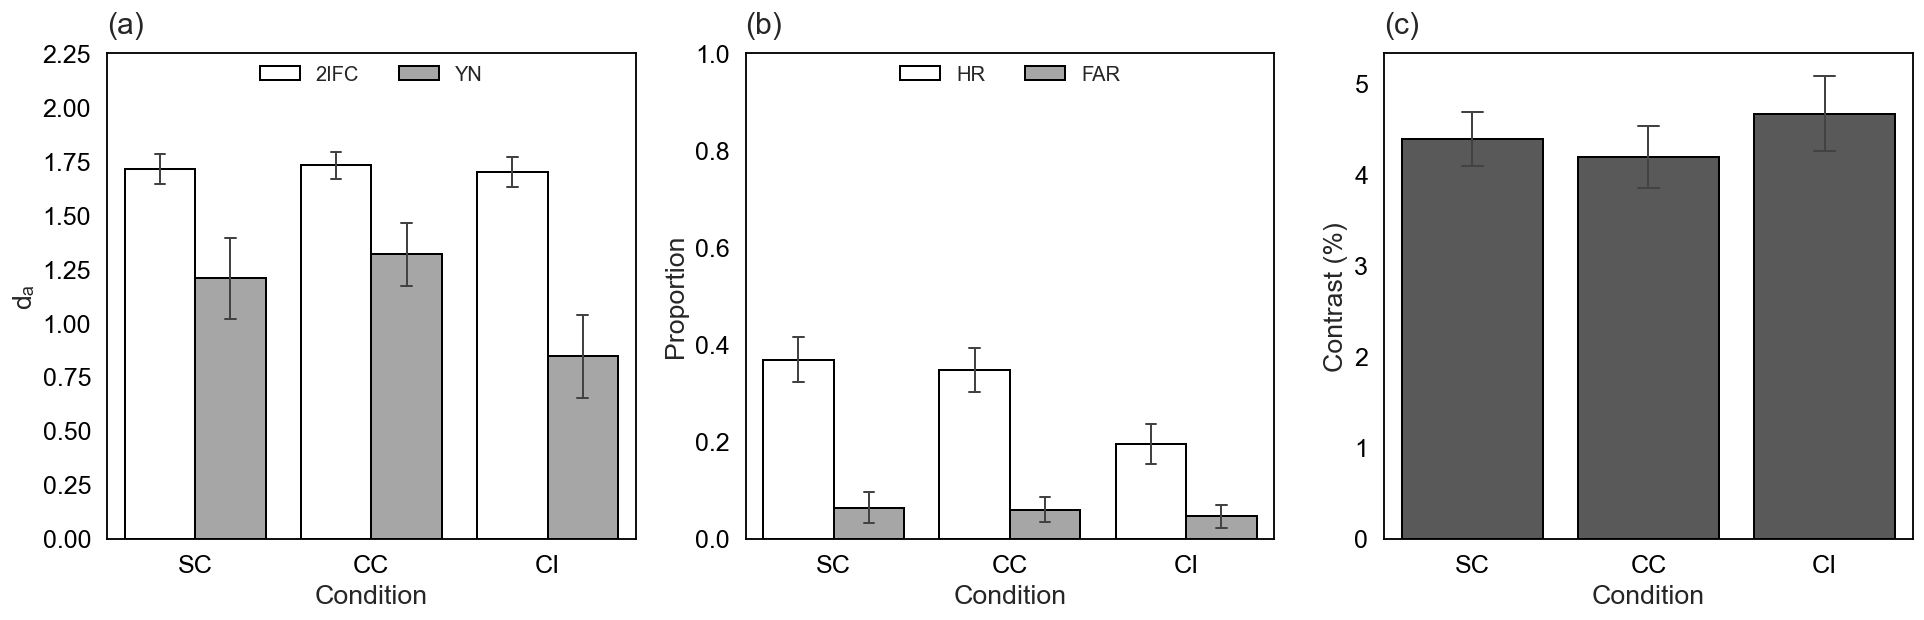

Figure saved to: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/figures/Supplementary_Figure_1_abc_ordinary_SEM.png


In [61]:
# =============================================================================
# Preliminary experiment group summary, panels (a)–(c)
#
# Panel (a): d_a for 2IFC and YN
# Panel (b): YN hit rate (HR) and false-alarm rate (FAR)
# Panel (c): 2IFC staircase contrast
#
# Error bars represent ordinary between-participant SEM.
# Individual participant markers are not displayed.
# =============================================================================

from matplotlib.patches import Rectangle

# -----------------------------------------------------------------------------
# Output directory
# -----------------------------------------------------------------------------

FIGURE_OUT = GROUP_OUT / "figures"
FIGURE_OUT.mkdir(parents=True, exist_ok=True)

CONDITION_ORDER = ["SC", "CC", "CI"]
TASK_ORDER = ["2IFC", "YN"]
METRIC_ORDER = ["HR", "FAR"]


# -----------------------------------------------------------------------------
# Figure style
# -----------------------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 12,
    "legend.title_fontsize": 13,
})

sns.set_style("white")


# -----------------------------------------------------------------------------
# Helper functions
# -----------------------------------------------------------------------------

def participant_summary_dir(pid: str) -> Path:
    """Return the directory containing one participant's summary files."""
    return PARTICIPANT_OUT / pid


def find_raw_files(pid: str) -> list[Path]:
    """Return all raw CSV files for one participant."""
    participant_dir = DATA_DIR / pid

    return sorted(
        participant_dir.glob(
            f"participant_{pid}_day*_block*.csv"
        )
    )


def load_meta_summary(pid: str, task: str) -> pd.DataFrame:
    """Load one participant's 2IFC or YN meta-d summary file."""
    file_path = (
        participant_summary_dir(pid)
        / f"{pid}_{task}_meta.csv"
    )

    if not file_path.is_file():
        raise FileNotFoundError(
            f"Meta-d summary not found: {file_path}\n"
            "Run the participant-level analysis before generating Supplementary Figure 1."
        )

    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if "Condition" not in df.columns:
        df = df.rename(
            columns={df.columns[0]: "Condition"}
        )

    required_columns = {"Condition", "da"}
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise KeyError(
            f"{file_path.name} is missing required columns: "
            + ", ".join(sorted(missing_columns))
        )

    df["Subject"] = pid

    return df


def load_hrfar_summary(pid: str) -> pd.DataFrame:
    """Load one participant's YN hit-rate and false-alarm-rate summary."""
    file_path = (
        participant_summary_dir(pid)
        / f"{pid}_yn_hr_far.csv"
    )

    if not file_path.is_file():
        raise FileNotFoundError(
            f"HR/FAR summary not found: {file_path}\n"
            "Run the participant-level analysis before generating Figure 2."
        )

    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if "Condition" not in df.columns:
        df = df.rename(
            columns={df.columns[0]: "Condition"}
        )

    required_columns = {"Condition", "HR", "FAR"}
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise KeyError(
            f"{file_path.name} is missing required columns: "
            + ", ".join(sorted(missing_columns))
        )

    df["Subject"] = pid

    return df


def format_axes(ax: plt.Axes) -> None:
    """Apply consistent journal-style axis formatting."""
    ax.grid(False)

    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.1)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        colors="black",
    )


# =============================================================================
# Panel (a): d_a
# =============================================================================

rows_da = []

for pid in PARTICIPANTS:

    df_2ifc = load_meta_summary(
        pid,
        "2ifc",
    )

    df_yn = load_meta_summary(
        pid,
        "yn",
    )

    for condition in CONDITION_ORDER:

        values_2ifc = df_2ifc.loc[
            df_2ifc["Condition"] == condition,
            "da",
        ].to_numpy()

        values_yn = df_yn.loc[
            df_yn["Condition"] == condition,
            "da",
        ].to_numpy()

        if values_2ifc.size != 1:
            raise ValueError(
                f"Expected exactly one 2IFC d_a value for "
                f"participant {pid}, condition {condition}; "
                f"found {values_2ifc.size}."
            )

        if values_yn.size != 1:
            raise ValueError(
                f"Expected exactly one YN d_a value for "
                f"participant {pid}, condition {condition}; "
                f"found {values_yn.size}."
            )

        rows_da.extend([
            {
                "Subject": pid,
                "Condition": condition,
                "Task": "2IFC",
                "da": float(values_2ifc[0]),
            },
            {
                "Subject": pid,
                "Condition": condition,
                "Task": "YN",
                "da": float(values_yn[0]),
            },
        ])


df_da = pd.DataFrame(rows_da)

df_da["da"] = pd.to_numeric(
    df_da["da"],
    errors="raise",
)

df_da["Condition"] = pd.Categorical(
    df_da["Condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

df_da["Task"] = pd.Categorical(
    df_da["Task"],
    categories=TASK_ORDER,
    ordered=True,
)


# =============================================================================
# Panel (b): YN HR and FAR
# =============================================================================

hrfar_frames = [
    load_hrfar_summary(pid)
    for pid in PARTICIPANTS
]

df_hrfar = pd.concat(
    hrfar_frames,
    ignore_index=True,
)

hrfar_long = pd.melt(
    df_hrfar[
        [
            "Subject",
            "Condition",
            "HR",
            "FAR",
        ]
    ],
    id_vars=[
        "Subject",
        "Condition",
    ],
    value_vars=[
        "HR",
        "FAR",
    ],
    var_name="Metric",
    value_name="Rate",
)

hrfar_long["Rate"] = pd.to_numeric(
    hrfar_long["Rate"],
    errors="raise",
)

hrfar_long["Condition"] = pd.Categorical(
    hrfar_long["Condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

hrfar_long["Metric"] = pd.Categorical(
    hrfar_long["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)


# =============================================================================
# Panel (c): 2IFC staircase contrast
#
# One mean contrast value is calculated for each participant and condition.
# Contrast proportions are converted to percentages.
# =============================================================================

staircase_frames = []

for pid in PARTICIPANTS:

    raw_files = find_raw_files(pid)

    if not raw_files:
        raise FileNotFoundError(
            f"No raw CSV files found for participant {pid}: "
            f"{DATA_DIR / pid}"
        )

    df_raw = pd.concat(
        [
            pd.read_csv(file_path)
            for file_path in raw_files
        ],
        ignore_index=True,
    )

    df_raw.columns = (
        df_raw.columns
        .str.strip()
    )

    required_columns = {
        "Task",
        "Category",
        "Contrast",
    }

    missing_columns = (
        required_columns
        .difference(df_raw.columns)
    )

    if missing_columns:
        raise KeyError(
            f"Participant {pid} is missing required staircase columns: "
            + ", ".join(sorted(missing_columns))
        )

    df_2ifc = df_raw.loc[
        df_raw["Task"] == "2IFC"
    ].copy()

    if df_2ifc.empty:
        raise ValueError(
            f"No 2IFC trials found for participant {pid}."
        )

    participant_staircase = (
        df_2ifc
        .groupby(
            "Category",
            observed=False,
        )["Contrast"]
        .mean()
        .reset_index()
        .rename(
            columns={
                "Category": "Condition",
                "Contrast": "contrast",
            }
        )
    )

    participant_staircase["contrast"] = (
        pd.to_numeric(
            participant_staircase["contrast"],
            errors="raise",
        )
        * 100
    )

    participant_staircase["Subject"] = pid

    staircase_frames.append(
        participant_staircase[
            [
                "Subject",
                "Condition",
                "contrast",
            ]
        ]
    )


df_staircase = pd.concat(
    staircase_frames,
    ignore_index=True,
)

df_staircase["Condition"] = pd.Categorical(
    df_staircase["Condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)


# =============================================================================
# Validate participant counts
# =============================================================================

expected_n = len(PARTICIPANTS)

for data_name, dataframe in {
    "d_a": df_da,
    "HR/FAR": hrfar_long,
    "staircase contrast": df_staircase,
}.items():

    observed_n = (
        dataframe["Subject"]
        .nunique()
    )

    if observed_n != expected_n:
        raise ValueError(
            f"{data_name}: expected {expected_n} participants, "
            f"but found {observed_n}."
        )


print(
    f"Figure 2 input data validated for "
    f"{expected_n} participants."
)


# =============================================================================
# Plot Figure 2, panels (a)–(c)
# =============================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5.8),
    dpi=120,
)

palette_two = [
    "white",
    "0.65",
]

bar_gray = "0.35"


# -----------------------------------------------------------------------------
# Panel (a): d_a
# -----------------------------------------------------------------------------

ax = axes[0]

sns.barplot(
    data=df_da,
    x="Condition",
    y="da",
    hue="Task",
    order=CONDITION_ORDER,
    hue_order=TASK_ORDER,
    palette=palette_two,
    edgecolor="black",
    linewidth=1.2,
    errorbar="se",
    capsize=0.12,
    err_kws={
        "linewidth": 1.2,
    },
    ax=ax,
)

ax.set_title(
    "(a)",
    loc="left",
    pad=12,
)

ax.set_xlabel(
    "Condition"
)

ax.set_ylabel(
    "dₐ"
)

ax.set_ylim(
    0,
    2.25,
)

format_axes(ax)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        1.00,
    ),
    frameon=False,
    ncol=2,
    borderaxespad=0.2,
)


# -----------------------------------------------------------------------------
# Panel (b): HR and FAR
# -----------------------------------------------------------------------------

ax = axes[1]

sns.barplot(
    data=hrfar_long,
    x="Condition",
    y="Rate",
    hue="Metric",
    order=CONDITION_ORDER,
    hue_order=METRIC_ORDER,
    palette=palette_two,
    edgecolor="black",
    linewidth=1.2,
    errorbar="se",
    capsize=0.12,
    err_kws={
        "linewidth": 1.2,
    },
    ax=ax,
)

ax.set_title(
    "(b)",
    loc="left",
    pad=12,
)

ax.set_xlabel(
    "Condition"
)

ax.set_ylabel(
    "Proportion"
)

ax.set_ylim(
    0,
    1,
)

format_axes(ax)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        1.00,
    ),
    frameon=False,
    ncol=2,
    borderaxespad=0.2,
)


# -----------------------------------------------------------------------------
# Panel (c): 2IFC staircase contrast
# -----------------------------------------------------------------------------

ax = axes[2]

sns.barplot(
    data=df_staircase,
    x="Condition",
    y="contrast",
    order=CONDITION_ORDER,
    color=bar_gray,
    edgecolor="black",
    linewidth=1.2,
    errorbar="se",
    capsize=0.12,
    err_kws={
        "linewidth": 1.2,
    },
    ax=ax,
)

ax.set_title(
    "(c)",
    loc="left",
    pad=12,
)

ax.set_xlabel(
    "Condition"
)

ax.set_ylabel(
    "Contrast (%)"
)

format_axes(ax)


# -----------------------------------------------------------------------------
# Outer figure border and layout
# -----------------------------------------------------------------------------

fig.tight_layout(
    rect=[
        0.02,
        0.03,
        0.98,
        0.97,
    ]
)


# =============================================================================
# Save figure and source data
# =============================================================================

figure_path = (
    FIGURE_OUT
    / "Supplementary_Figure_1_abc_ordinary_SEM.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)


# Save participant-level source values used to generate each panel.

df_da.to_csv(
    GROUP_OUT
    / "Supplementary_Figure_1a_detectability_source_data.csv",
    index=False,
)

hrfar_long.to_csv(
    GROUP_OUT
    / "Supplementary_Figure_1b_hr_far_source_data.csv",
    index=False,
)

df_staircase.to_csv(
    GROUP_OUT
    / "Supplementary_Figure_1c_staircase_source_data.csv",
    index=False,
)


plt.show()
plt.close(fig)

print(
    f"Figure saved to: {figure_path}"
)


## Statistical analyses: Preliminary_experiment

Repeated-measures ANOVAs and Bonferroni-corrected paired comparisons for
working-memory accuracy, perceptual performance, sensitivity, metacognitive
sensitivity, hit and false-alarm rates, and staircase contrast.

In [55]:
# =============================================================================
# Preliminary_experiment statistical analyses
#
# 1. WM accuracy: Phase × Condition
# 2. Perceptual accuracy: Task × Condition
# 3. d_a: Task × Condition and task-specific one-way analyses
# 4. YN / 2IFC d_a ratio
# 5. YN d_a versus scaled 2IFC d_a
# 6. YN hit and false-alarm rates
# 7. 2IFC staircase contrast
# 8. 2IFC and YN meta-d_a
# 9. One-factor Mauchly sphericity checks
#
# One-way rmANOVAs use correction="auto".
# Two-way rmANOVAs return both uncorrected and GG-corrected p-values because
# Pingouin does not implement effect-specific Mauchly tests for two-way designs.
# =============================================================================

import pingouin as pg

# -----------------------------------------------------------------------------
# Output directory
# -----------------------------------------------------------------------------

STATISTICS_OUT = GROUP_OUT / "statistics"
STATISTICS_OUT.mkdir(parents=True, exist_ok=True)

CONDITION_ORDER = ["SC", "CC", "CI"]
TASK_ORDER = ["2IFC", "YN"]
PHASE_ORDER = ["After 2IFC", "After YN"]
MEASURE_ORDER = ["HR", "FAR"]


# -----------------------------------------------------------------------------
# General helper functions
# -----------------------------------------------------------------------------

def save_statistics(
    dataframe: pd.DataFrame,
    filename: str,
    *,
    index: bool = False,
) -> None:
    """Save one statistical output table as CSV."""
    output_path = STATISTICS_OUT / filename
    dataframe.to_csv(output_path, index=index)
    print(f"Saved statistics: {output_path}")


def available_columns(
    dataframe: pd.DataFrame,
    requested_columns: list[str],
) -> list[str]:
    """Return requested columns that are present in a dataframe."""
    return [
        column
        for column in requested_columns
        if column in dataframe.columns
    ]


def display_pairwise(
    dataframe: pd.DataFrame,
    title: str,
    filename: str,
) -> None:
    """Print and save a Pingouin pairwise-comparison table."""
    preferred_columns = [
        "Contrast",
        "Task",
        "Phase",
        "Measure",
        "Condition",
        "Category",
        "A",
        "B",
        "Paired",
        "Parametric",
        "T",
        "dof",
        "alternative",
        "p_unc",
        "p_corr",
        "p_adjust",
        "BF10",
        "hedges",
    ]

    columns = available_columns(
        dataframe,
        preferred_columns,
    )

    print(f"\n--- {title} ---")
    print(dataframe[columns].to_string(index=False))

    save_statistics(
        dataframe,
        filename,
        index=False,
    )


def validate_repeated_cells(
    dataframe: pd.DataFrame,
    *,
    subject: str,
    within: list[str],
    expected_subjects: int,
    data_name: str,
) -> None:
    """Confirm that every participant has one row in every repeated cell."""
    expected_cells = 1

    for factor in within:
        expected_cells *= dataframe[factor].nunique()

    observed = (
        dataframe
        .groupby(subject, observed=True)
        .size()
    )

    missing_subjects = (
        set(PARTICIPANTS)
        - set(dataframe[subject].astype(str).unique())
    )

    incomplete_subjects = observed[
        observed != expected_cells
    ]

    if missing_subjects or not incomplete_subjects.empty:
        messages = [f"Incomplete repeated-measures data: {data_name}."]

        if missing_subjects:
            messages.append(
                "Missing participants: "
                + ", ".join(sorted(missing_subjects))
            )

        if not incomplete_subjects.empty:
            messages.append(
                "Unexpected cell counts:\n"
                + incomplete_subjects.to_string()
            )

        raise ValueError("\n".join(messages))

    if dataframe[subject].nunique() != expected_subjects:
        raise ValueError(
            f"{data_name}: expected {expected_subjects} participants, "
            f"but found {dataframe[subject].nunique()}."
        )


def run_oneway_rm_anova(
    dataframe: pd.DataFrame,
    *,
    dv: str,
    within: str,
    subject: str,
    title: str,
    filename: str,
) -> pd.DataFrame:
    """Run and save a one-way repeated-measures ANOVA."""
    result = pg.rm_anova(
        data=dataframe,
        dv=dv,
        within=within,
        subject=subject,
        correction="auto",
        detailed=True,
        effsize="ng2",
    )

    print(f"\n=== {title} ===")
    print(result.to_string(index=False))

    save_statistics(
        result,
        filename,
        index=False,
    )

    return result


def run_twoway_rm_anova(
    dataframe: pd.DataFrame,
    *,
    dv: str,
    within: list[str],
    subject: str,
    title: str,
    filename: str,
) -> pd.DataFrame:
    """Run and save a two-way repeated-measures ANOVA."""
    result = pg.rm_anova(
        data=dataframe,
        dv=dv,
        within=within,
        subject=subject,
        correction=True,
        detailed=True,
        effsize="ng2",
    )

    print(f"\n=== {title} ===")
    print(result.to_string(index=False))

    save_statistics(
        result,
        filename,
        index=False,
    )

    return result


def run_pairwise_tests(
    dataframe: pd.DataFrame,
    *,
    dv: str,
    within: str | list[str],
    subject: str,
    title: str,
    filename: str,
) -> pd.DataFrame:
    """Run Bonferroni-corrected two-sided paired comparisons."""
    result = pg.pairwise_tests(
        data=dataframe,
        dv=dv,
        within=within,
        subject=subject,
        padjust="bonf",
        effsize="hedges",
        alternative="two-sided",
        nan_policy="listwise",
    )

    display_pairwise(
        result,
        title,
        filename,
    )

    return result


def load_raw_subject(pid: str) -> pd.DataFrame:
    """Load and concatenate all raw CSV files for one participant."""
    participant_directory = DATA_DIR / pid
    raw_files = sorted(
        participant_directory.glob(
            f"participant_{pid}_day*_block*.csv"
        )
    )

    if not raw_files:
        raise FileNotFoundError(
            f"No raw files found for participant {pid}: "
            f"{participant_directory}"
        )

    dataframe = pd.concat(
        [pd.read_csv(file_path) for file_path in raw_files],
        ignore_index=True,
    )
    dataframe.columns = dataframe.columns.str.strip()
    dataframe = dataframe.reset_index(drop=True)
    dataframe["Subject"] = pid

    return dataframe


def load_participant_summary(
    pid: str,
    task: str,
) -> pd.DataFrame:
    """Load one participant's 2IFC or YN meta-analysis summary."""
    file_path = (
        PARTICIPANT_OUT
        / pid
        / f"{pid}_{task}_meta.csv"
    )

    if not file_path.is_file():
        raise FileNotFoundError(
            f"Summary file not found: {file_path}\n"
            "Run the participant-level analysis cell first."
        )

    dataframe = pd.read_csv(file_path)
    dataframe.columns = dataframe.columns.str.strip()

    if "Condition" not in dataframe.columns:
        dataframe = dataframe.rename(
            columns={dataframe.columns[0]: "Condition"}
        )

    required_columns = {
        "Condition",
        "da",
        "meta_da",
    }
    missing_columns = required_columns.difference(
        dataframe.columns
    )

    if missing_columns:
        raise KeyError(
            f"{file_path.name} is missing columns: "
            + ", ".join(sorted(missing_columns))
        )

    dataframe["Subject"] = pid
    return dataframe


def load_hrfar_summary(pid: str) -> pd.DataFrame:
    """Load one participant's YN HR/FAR summary."""
    file_path = (
        PARTICIPANT_OUT
        / pid
        / f"{pid}_yn_hr_far.csv"
    )

    if not file_path.is_file():
        raise FileNotFoundError(
            f"HR/FAR summary not found: {file_path}\n"
            "Run the participant-level analysis cell first."
        )

    dataframe = pd.read_csv(file_path)
    dataframe.columns = dataframe.columns.str.strip()

    if "Condition" not in dataframe.columns:
        dataframe = dataframe.rename(
            columns={dataframe.columns[0]: "Condition"}
        )

    required_columns = {
        "Condition",
        "HR",
        "FAR",
    }
    missing_columns = required_columns.difference(
        dataframe.columns
    )

    if missing_columns:
        raise KeyError(
            f"{file_path.name} is missing columns: "
            + ", ".join(sorted(missing_columns))
        )

    dataframe["Subject"] = pid
    return dataframe


# =============================================================================
# Load participant-level raw accuracy data
# =============================================================================

task_accuracy_frames = []
wm_accuracy_frames = []
contrast_frames = []

for pid in PARTICIPANTS:
    df_raw = load_raw_subject(pid)

    required_accuracy_columns = {
        "Task",
        "Category",
        "Combined_Correct",
    }
    missing_accuracy_columns = (
        required_accuracy_columns
        .difference(df_raw.columns)
    )

    if missing_accuracy_columns:
        raise KeyError(
            f"Participant {pid} is missing columns: "
            + ", ".join(sorted(missing_accuracy_columns))
        )

    df_raw["Combined_Correct"] = pd.to_numeric(
        df_raw["Combined_Correct"],
        errors="raise",
    )

    # -------------------------------------------------------------------------
    # Perceptual-task accuracy
    # -------------------------------------------------------------------------

    perceptual_trials = df_raw.loc[
        df_raw["Task"].isin(TASK_ORDER)
        & df_raw["Category"].isin(CONDITION_ORDER)
    ].copy()

    participant_task_accuracy = (
        perceptual_trials
        .groupby(
            ["Subject", "Task", "Category"],
            observed=False,
        )["Combined_Correct"]
        .mean()
        .reset_index()
        .rename(
            columns={"Combined_Correct": "Accuracy"}
        )
    )

    participant_task_accuracy["Accuracy"] *= 100
    task_accuracy_frames.append(
        participant_task_accuracy
    )

    # -------------------------------------------------------------------------
    # WM accuracy after 2IFC versus after YN
    # -------------------------------------------------------------------------

    previous_task = df_raw["Task"].shift(1)

    df_raw["FollowedBy"] = np.where(
        df_raw["Task"].eq("WM_probe"),
        previous_task,
        np.nan,
    )

    wm_trials = df_raw.loc[
        df_raw["Task"].eq("WM_probe")
        & df_raw["FollowedBy"].isin(TASK_ORDER)
        & df_raw["Category"].isin(CONDITION_ORDER)
    ].copy()

    participant_wm_accuracy = (
        wm_trials
        .groupby(
            ["Subject", "FollowedBy", "Category"],
            observed=False,
        )["Combined_Correct"]
        .mean()
        .reset_index()
        .rename(
            columns={"Combined_Correct": "Accuracy"}
        )
    )

    participant_wm_accuracy["Accuracy"] *= 100
    participant_wm_accuracy["Phase"] = (
        participant_wm_accuracy["FollowedBy"]
        .map({
            "2IFC": "After 2IFC",
            "YN": "After YN",
        })
    )

    wm_accuracy_frames.append(
        participant_wm_accuracy[
            ["Subject", "Phase", "Category", "Accuracy"]
        ]
    )

    # -------------------------------------------------------------------------
    # 2IFC staircase contrast
    # -------------------------------------------------------------------------

    required_contrast_columns = {
        "Task",
        "Category",
        "Contrast",
    }
    missing_contrast_columns = (
        required_contrast_columns
        .difference(df_raw.columns)
    )

    if missing_contrast_columns:
        raise KeyError(
            f"Participant {pid} is missing contrast columns: "
            + ", ".join(sorted(missing_contrast_columns))
        )

    contrast_trials = df_raw.loc[
        df_raw["Task"].eq("2IFC")
        & df_raw["Category"].isin(CONDITION_ORDER)
    ].copy()

    contrast_trials["Contrast"] = pd.to_numeric(
        contrast_trials["Contrast"],
        errors="raise",
    )

    participant_contrast = (
        contrast_trials
        .groupby(
            ["Subject", "Category"],
            observed=False,
        )["Contrast"]
        .mean()
        .reset_index()
    )

    contrast_frames.append(participant_contrast)


df_task_acc = pd.concat(
    task_accuracy_frames,
    ignore_index=True,
)
df_wm_acc = pd.concat(
    wm_accuracy_frames,
    ignore_index=True,
)
df_contrast = pd.concat(
    contrast_frames,
    ignore_index=True,
)

df_task_acc["Task"] = pd.Categorical(
    df_task_acc["Task"],
    categories=TASK_ORDER,
    ordered=True,
)
df_task_acc["Category"] = pd.Categorical(
    df_task_acc["Category"],
    categories=CONDITION_ORDER,
    ordered=True,
)

df_wm_acc["Phase"] = pd.Categorical(
    df_wm_acc["Phase"],
    categories=PHASE_ORDER,
    ordered=True,
)
df_wm_acc["Category"] = pd.Categorical(
    df_wm_acc["Category"],
    categories=CONDITION_ORDER,
    ordered=True,
)

df_contrast["Category"] = pd.Categorical(
    df_contrast["Category"],
    categories=CONDITION_ORDER,
    ordered=True,
)


# =============================================================================
# Load participant-level d_a and meta-d_a summaries
# =============================================================================

twoifc_frames = []
yn_frames = []
hrfar_frames = []

for pid in PARTICIPANTS:
    twoifc_frames.append(
        load_participant_summary(pid, "2ifc")
    )
    yn_frames.append(
        load_participant_summary(pid, "yn")
    )
    hrfar_frames.append(
        load_hrfar_summary(pid)
    )

df_2ifc_all = pd.concat(
    twoifc_frames,
    ignore_index=True,
)
df_yn_all = pd.concat(
    yn_frames,
    ignore_index=True,
)
df_yn_hrfar = pd.concat(
    hrfar_frames,
    ignore_index=True,
)

for dataframe in [df_2ifc_all, df_yn_all, df_yn_hrfar]:
    dataframe["Condition"] = pd.Categorical(
        dataframe["Condition"],
        categories=CONDITION_ORDER,
        ordered=True,
    )

for dataframe, columns in [
    (df_2ifc_all, ["da", "meta_da"]),
    (df_yn_all, ["da", "meta_da"]),
    (df_yn_hrfar, ["HR", "FAR"]),
]:
    for column in columns:
        dataframe[column] = pd.to_numeric(
            dataframe[column],
            errors="raise",
        )


# =============================================================================
# Validate repeated-measures datasets
# =============================================================================

expected_n = len(PARTICIPANTS)

validate_repeated_cells(
    df_task_acc,
    subject="Subject",
    within=["Task", "Category"],
    expected_subjects=expected_n,
    data_name="perceptual-task accuracy",
)

validate_repeated_cells(
    df_wm_acc,
    subject="Subject",
    within=["Phase", "Category"],
    expected_subjects=expected_n,
    data_name="WM accuracy",
)

validate_repeated_cells(
    df_2ifc_all,
    subject="Subject",
    within=["Condition"],
    expected_subjects=expected_n,
    data_name="2IFC d_a/meta-d_a",
)

validate_repeated_cells(
    df_yn_all,
    subject="Subject",
    within=["Condition"],
    expected_subjects=expected_n,
    data_name="YN d_a/meta-d_a",
)

validate_repeated_cells(
    df_yn_hrfar,
    subject="Subject",
    within=["Condition"],
    expected_subjects=expected_n,
    data_name="YN HR/FAR",
)

validate_repeated_cells(
    df_contrast,
    subject="Subject",
    within=["Category"],
    expected_subjects=expected_n,
    data_name="2IFC staircase contrast",
)

print(
    f"Statistical input data validated for "
    f"{expected_n} participants."
)


# =============================================================================
# Save source datasets used in statistical analyses
# =============================================================================

save_statistics(
    df_wm_acc,
    "source_wm_accuracy.csv",
)
save_statistics(
    df_task_acc,
    "source_perceptual_accuracy.csv",
)
save_statistics(
    df_2ifc_all[
        ["Subject", "Condition", "da", "meta_da"]
    ],
    "source_2ifc_da_meta_da.csv",
)
save_statistics(
    df_yn_all[
        ["Subject", "Condition", "da", "meta_da"]
    ],
    "source_yn_da_meta_da.csv",
)
save_statistics(
    df_yn_hrfar[
        ["Subject", "Condition", "HR", "FAR"]
    ],
    "source_yn_hr_far.csv",
)
save_statistics(
    df_contrast,
    "source_2ifc_staircase_contrast.csv",
)


# =============================================================================
# 1. WM accuracy: Phase × Condition
# =============================================================================

print("\n" + "=" * 72)
print("1. WM accuracy: Phase × Condition")
print("=" * 72)

wm_descriptives = (
    df_wm_acc
    .groupby(
        ["Phase", "Category"],
        observed=False,
    )["Accuracy"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nWM accuracy descriptives:")
print(wm_descriptives.to_string(index=False))

save_statistics(
    wm_descriptives,
    "01_wm_accuracy_descriptives.csv",
)

aov_wm_acc = run_twoway_rm_anova(
    df_wm_acc,
    dv="Accuracy",
    within=["Phase", "Category"],
    subject="Subject",
    title="2 × 3 rmANOVA: WM accuracy",
    filename="01_wm_accuracy_rmANOVA.csv",
)

post_wm_acc = run_pairwise_tests(
    df_wm_acc,
    dv="Accuracy",
    within=["Phase", "Category"],
    subject="Subject",
    title="WM accuracy pairwise comparisons",
    filename="01_wm_accuracy_pairwise.csv",
)


# =============================================================================
# 2. Perceptual accuracy: Task × Condition
# =============================================================================

print("\n" + "=" * 72)
print("2. Perceptual accuracy: Task × Condition")
print("=" * 72)

task_accuracy_descriptives = (
    df_task_acc
    .groupby(
        ["Task", "Category"],
        observed=False,
    )["Accuracy"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nPerceptual accuracy descriptives:")
print(task_accuracy_descriptives.to_string(index=False))

save_statistics(
    task_accuracy_descriptives,
    "02_perceptual_accuracy_descriptives.csv",
)

aov_task_acc = run_twoway_rm_anova(
    df_task_acc,
    dv="Accuracy",
    within=["Task", "Category"],
    subject="Subject",
    title="2 × 3 rmANOVA: perceptual accuracy",
    filename="02_perceptual_accuracy_rmANOVA.csv",
)

post_task_acc = run_pairwise_tests(
    df_task_acc,
    dv="Accuracy",
    within=["Task", "Category"],
    subject="Subject",
    title="Perceptual accuracy pairwise comparisons",
    filename="02_perceptual_accuracy_pairwise.csv",
)


# =============================================================================
# 3. d_a: Task × Condition
# =============================================================================

print("\n" + "=" * 72)
print("3. d_a: Task × Condition")
print("=" * 72)

df_2ifc_da_long = (
    df_2ifc_all[
        ["Subject", "Condition", "da"]
    ]
    .copy()
)
df_2ifc_da_long["Task"] = "2IFC"

df_yn_da_long = (
    df_yn_all[
        ["Subject", "Condition", "da"]
    ]
    .copy()
)
df_yn_da_long["Task"] = "YN"

df_da_2x3 = pd.concat(
    [df_2ifc_da_long, df_yn_da_long],
    ignore_index=True,
)

df_da_2x3["Task"] = pd.Categorical(
    df_da_2x3["Task"],
    categories=TASK_ORDER,
    ordered=True,
)
df_da_2x3["Condition"] = pd.Categorical(
    df_da_2x3["Condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

validate_repeated_cells(
    df_da_2x3,
    subject="Subject",
    within=["Task", "Condition"],
    expected_subjects=expected_n,
    data_name="d_a Task × Condition",
)

da_descriptives = (
    df_da_2x3
    .groupby(
        ["Task", "Condition"],
        observed=False,
    )["da"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nd_a descriptives:")
print(da_descriptives.to_string(index=False))

save_statistics(
    da_descriptives,
    "03_da_descriptives.csv",
)

aov_da_2x3 = run_twoway_rm_anova(
    df_da_2x3,
    dv="da",
    within=["Task", "Condition"],
    subject="Subject",
    title="2 × 3 rmANOVA: d_a",
    filename="03_da_task_condition_rmANOVA.csv",
)

post_da_2x3 = run_pairwise_tests(
    df_da_2x3,
    dv="da",
    within=["Task", "Condition"],
    subject="Subject",
    title="d_a pairwise comparisons",
    filename="03_da_task_condition_pairwise.csv",
)

aov_2ifc_da = run_oneway_rm_anova(
    df_2ifc_all,
    dv="da",
    within="Condition",
    subject="Subject",
    title="One-way rmANOVA: 2IFC d_a",
    filename="03a_2ifc_da_rmANOVA.csv",
)

aov_yn_da = run_oneway_rm_anova(
    df_yn_all,
    dv="da",
    within="Condition",
    subject="Subject",
    title="One-way rmANOVA: YN d_a",
    filename="03b_yn_da_rmANOVA.csv",
)


# =============================================================================
# 4. Ratio: YN d_a / 2IFC d_a
# =============================================================================

print("\n" + "=" * 72)
print("4. Ratio: YN d_a / 2IFC d_a")
print("=" * 72)

df_ratio = pd.merge(
    df_yn_all[
        ["Subject", "Condition", "da"]
    ],
    df_2ifc_all[
        ["Subject", "Condition", "da"]
    ],
    on=["Subject", "Condition"],
    suffixes=("_yn", "_2ifc"),
    validate="one_to_one",
)

if (df_ratio["da_2ifc"] == 0).any():
    zero_rows = df_ratio.loc[
        df_ratio["da_2ifc"] == 0,
        ["Subject", "Condition"],
    ]

    raise ZeroDivisionError(
        "Cannot calculate YN/2IFC ratio because 2IFC d_a "
        "equals zero for:\n"
        + zero_rows.to_string(index=False)
    )

df_ratio["da_ratio"] = (
    df_ratio["da_yn"]
    / df_ratio["da_2ifc"]
)

df_ratio["Condition"] = pd.Categorical(
    df_ratio["Condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

ratio_descriptives = (
    df_ratio
    .groupby(
        "Condition",
        observed=False,
    )["da_ratio"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nRatio descriptives:")
print(ratio_descriptives.to_string(index=False))

save_statistics(
    df_ratio,
    "source_da_ratio.csv",
)
save_statistics(
    ratio_descriptives,
    "04_da_ratio_descriptives.csv",
)

aov_ratio = run_oneway_rm_anova(
    df_ratio,
    dv="da_ratio",
    within="Condition",
    subject="Subject",
    title="One-way rmANOVA: YN/2IFC d_a ratio",
    filename="04_da_ratio_rmANOVA.csv",
)

post_ratio = run_pairwise_tests(
    df_ratio,
    dv="da_ratio",
    within="Condition",
    subject="Subject",
    title="YN/2IFC d_a ratio pairwise comparisons",
    filename="04_da_ratio_pairwise.csv",
)


# =============================================================================
# 5. YN d_a versus 2IFC d_a / sqrt(2)
# =============================================================================

print("\n" + "=" * 72)
print("5. YN d_a versus scaled 2IFC d_a")
print("=" * 72)

df_scaled = pd.merge(
    df_yn_all[
        ["Subject", "Condition", "da"]
    ],
    df_2ifc_all[
        ["Subject", "Condition", "da"]
    ],
    on=["Subject", "Condition"],
    suffixes=("_yn", "_2ifc"),
    validate="one_to_one",
)

df_scaled["da_2ifc_scaled"] = (
    df_scaled["da_2ifc"]
    / np.sqrt(2)
)

df_scaled_long = pd.concat([
    df_scaled[
        ["Subject", "Condition", "da_2ifc_scaled"]
    ]
    .rename(columns={"da_2ifc_scaled": "da"})
    .assign(Task="Scaled 2IFC"),

    df_scaled[
        ["Subject", "Condition", "da_yn"]
    ]
    .rename(columns={"da_yn": "da"})
    .assign(Task="YN"),
], ignore_index=True)

df_scaled_long["Task"] = pd.Categorical(
    df_scaled_long["Task"],
    categories=["Scaled 2IFC", "YN"],
    ordered=True,
)
df_scaled_long["Condition"] = pd.Categorical(
    df_scaled_long["Condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

scaled_descriptives = (
    df_scaled_long
    .groupby(
        ["Task", "Condition"],
        observed=False,
    )["da"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nScaled d_a descriptives:")
print(scaled_descriptives.to_string(index=False))

save_statistics(
    df_scaled,
    "source_scaled_2ifc_vs_yn_da.csv",
)
save_statistics(
    scaled_descriptives,
    "05_scaled_da_descriptives.csv",
)

aov_scaled = run_twoway_rm_anova(
    df_scaled_long,
    dv="da",
    within=["Task", "Condition"],
    subject="Subject",
    title="2 × 3 rmANOVA: scaled 2IFC versus YN d_a",
    filename="05_scaled_da_rmANOVA.csv",
)

conditionwise_scaled_tests = []

for condition in CONDITION_ORDER:
    condition_data = df_scaled.loc[
        df_scaled["Condition"] == condition
    ].copy()

    test_result = pg.ttest(
        condition_data["da_yn"],
        condition_data["da_2ifc_scaled"],
        paired=True,
        alternative="two-sided",
    ).reset_index(drop=True)

    test_result["Condition"] = condition
    test_result["hedges"] = pg.compute_effsize(
        condition_data["da_yn"],
        condition_data["da_2ifc_scaled"],
        paired=True,
        eftype="hedges",
    )

    conditionwise_scaled_tests.append(test_result)

scaled_tests = pd.concat(
    conditionwise_scaled_tests,
    ignore_index=True,
)

# Bonferroni correction across the three condition-wise comparisons.
scaled_tests["p_corr"] = pg.multicomp(
    scaled_tests["p_val"].to_numpy(),
    method="bonf",
)[1]
scaled_tests["p_adjust"] = "bonf"

print("\nCondition-wise YN versus scaled 2IFC tests:")
print(scaled_tests.to_string(index=False))

save_statistics(
    scaled_tests,
    "05_scaled_da_conditionwise_tests.csv",
)


# =============================================================================
# 6. YN hit and false-alarm rates
# =============================================================================

print("\n" + "=" * 72)
print("6. YN hit and false-alarm rates")
print("=" * 72)

df_hr = df_yn_hrfar[
    ["Subject", "Condition", "HR"]
].copy()

df_far = df_yn_hrfar[
    ["Subject", "Condition", "FAR"]
].copy()

df_hrfar_long = pd.concat([
    df_hr.rename(columns={"HR": "Value"})
    .assign(Measure="HR"),

    df_far.rename(columns={"FAR": "Value"})
    .assign(Measure="FAR"),
], ignore_index=True)

df_hrfar_long["Measure"] = pd.Categorical(
    df_hrfar_long["Measure"],
    categories=MEASURE_ORDER,
    ordered=True,
)
df_hrfar_long["Condition"] = pd.Categorical(
    df_hrfar_long["Condition"],
    categories=CONDITION_ORDER,
    ordered=True,
)

hrfar_descriptives = (
    df_hrfar_long
    .groupby(
        ["Measure", "Condition"],
        observed=False,
    )["Value"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nHR/FAR descriptives:")
print(hrfar_descriptives.to_string(index=False))

save_statistics(
    hrfar_descriptives,
    "06_hr_far_descriptives.csv",
)

aov_hrfar = run_twoway_rm_anova(
    df_hrfar_long,
    dv="Value",
    within=["Measure", "Condition"],
    subject="Subject",
    title="2 × 3 rmANOVA: HR/FAR",
    filename="06_hr_far_rmANOVA.csv",
)

post_hrfar = run_pairwise_tests(
    df_hrfar_long,
    dv="Value",
    within=["Measure", "Condition"],
    subject="Subject",
    title="HR/FAR pairwise comparisons",
    filename="06_hr_far_pairwise.csv",
)

aov_hr = run_oneway_rm_anova(
    df_hr,
    dv="HR",
    within="Condition",
    subject="Subject",
    title="One-way rmANOVA: HR",
    filename="06a_hr_rmANOVA.csv",
)

post_hr = run_pairwise_tests(
    df_hr,
    dv="HR",
    within="Condition",
    subject="Subject",
    title="HR pairwise comparisons",
    filename="06a_hr_pairwise.csv",
)

aov_far = run_oneway_rm_anova(
    df_far,
    dv="FAR",
    within="Condition",
    subject="Subject",
    title="One-way rmANOVA: FAR",
    filename="06b_far_rmANOVA.csv",
)

post_far = run_pairwise_tests(
    df_far,
    dv="FAR",
    within="Condition",
    subject="Subject",
    title="FAR pairwise comparisons",
    filename="06b_far_pairwise.csv",
)


# =============================================================================
# 7. 2IFC staircase contrast
# =============================================================================

print("\n" + "=" * 72)
print("7. 2IFC staircase contrast")
print("=" * 72)

contrast_descriptives = (
    df_contrast
    .groupby(
        "Category",
        observed=False,
    )["Contrast"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print("\nStaircase contrast descriptives:")
print(contrast_descriptives.to_string(index=False))

save_statistics(
    contrast_descriptives,
    "07_staircase_contrast_descriptives.csv",
)

aov_contrast = run_oneway_rm_anova(
    df_contrast,
    dv="Contrast",
    within="Category",
    subject="Subject",
    title="One-way rmANOVA: 2IFC staircase contrast",
    filename="07_staircase_contrast_rmANOVA.csv",
)

post_contrast = run_pairwise_tests(
    df_contrast,
    dv="Contrast",
    within="Category",
    subject="Subject",
    title="2IFC staircase contrast pairwise comparisons",
    filename="07_staircase_contrast_pairwise.csv",
)


# =============================================================================
# 8. 2IFC and YN meta-d_a
# =============================================================================

print("\n" + "=" * 72)
print("8. 2IFC and YN meta-d_a")
print("=" * 72)

twoifc_meta_descriptives = (
    df_2ifc_all
    .groupby(
        "Condition",
        observed=False,
    )["meta_da"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

yn_meta_descriptives = (
    df_yn_all
    .groupby(
        "Condition",
        observed=False,
    )["meta_da"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

save_statistics(
    twoifc_meta_descriptives,
    "08a_2ifc_meta_da_descriptives.csv",
)
save_statistics(
    yn_meta_descriptives,
    "08b_yn_meta_da_descriptives.csv",
)

aov_2ifc_meta = run_oneway_rm_anova(
    df_2ifc_all,
    dv="meta_da",
    within="Condition",
    subject="Subject",
    title="One-way rmANOVA: 2IFC meta-d_a",
    filename="08a_2ifc_meta_da_rmANOVA.csv",
)

post_2ifc_meta = run_pairwise_tests(
    df_2ifc_all,
    dv="meta_da",
    within="Condition",
    subject="Subject",
    title="2IFC meta-d_a pairwise comparisons",
    filename="08a_2ifc_meta_da_pairwise.csv",
)

aov_yn_meta = run_oneway_rm_anova(
    df_yn_all,
    dv="meta_da",
    within="Condition",
    subject="Subject",
    title="One-way rmANOVA: YN meta-d_a",
    filename="08b_yn_meta_da_rmANOVA.csv",
)

post_yn_meta = run_pairwise_tests(
    df_yn_all,
    dv="meta_da",
    within="Condition",
    subject="Subject",
    title="YN meta-d_a pairwise comparisons",
    filename="08b_yn_meta_da_pairwise.csv",
)


# =============================================================================
# 9. Explicit one-factor Mauchly sphericity checks
# =============================================================================

print("\n" + "=" * 72)
print("9. One-factor Mauchly sphericity checks")
print("=" * 72)

sphericity_inputs = [
    (
        "2IFC d_a",
        df_2ifc_all,
        "da",
        "Condition",
    ),
    (
        "YN d_a",
        df_yn_all,
        "da",
        "Condition",
    ),
    (
        "YN/2IFC d_a ratio",
        df_ratio,
        "da_ratio",
        "Condition",
    ),
    (
        "2IFC meta-d_a",
        df_2ifc_all,
        "meta_da",
        "Condition",
    ),
    (
        "YN meta-d_a",
        df_yn_all,
        "meta_da",
        "Condition",
    ),
    (
        "HR",
        df_hr,
        "HR",
        "Condition",
    ),
    (
        "FAR",
        df_far,
        "FAR",
        "Condition",
    ),
    (
        "2IFC staircase contrast",
        df_contrast,
        "Contrast",
        "Category",
    ),
]

sphericity_rows = []

for analysis_name, dataframe, dv, within in sphericity_inputs:
    result = pg.sphericity(
        dataframe,
        dv=dv,
        subject="Subject",
        within=within,
    )

    sphericity_rows.append({
        "Analysis": analysis_name,
        "Sphericity": result.spher,
        "W": result.W,
        "chi2": result.chi2,
        "dof": result.dof,
        "p_value": result.pval,
    })

df_sphericity = pd.DataFrame(
    sphericity_rows
)

print(df_sphericity.to_string(index=False))

save_statistics(
    df_sphericity,
    "09_mauchly_sphericity_checks.csv",
)

print(
    "\nPreliminary_experiment statistical analyses completed successfully."
)
print(
    f"Statistical outputs saved to: {STATISTICS_OUT}"
)

Statistical input data validated for 16 participants.
Saved statistics: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/statistics/source_wm_accuracy.csv
Saved statistics: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/statistics/source_perceptual_accuracy.csv
Saved statistics: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/statistics/source_2ifc_da_meta_da.csv
Saved statistics: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/statistics/source_yn_da_meta_da.csv
Saved statistics: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/statistics/source_yn_hr_far.csv
Saved statistics: /Users/w/Documents/GitHub/Blindsight_WM/results/preliminary_experiment/group_summary/statistics/source_2ifc_staircase_contrast.csv

1. WM accuracy: Phase × Condition

WM accuracy descriptives:
     Phase Category      mean       st